# Описательный анализ (EDA): D004 (kv_vopr 0–12, 2021–2024) и агрегаты master_wide (D002 + D006 + D008) по годам

**Состав данных**
- `D004.zip` — 12 частей опросника (`kv_vopr_{0..7,9..12}_combined.csv`), сводные за 2021–2024, длинный формат (строка = домохозяйство × позиция × квартал).
- `master_wide_{2021..2024}.csv` — годовые широкие агрегаты по 510 колонкам: `d006__*` (244), `d002_ocenka__*` (116), `d002_subject__*` (108), `d008__*` (30) и 12 ключевых/итоговых колонок.
- `структура_датасетов_и_опросники.zip` — формы опросников и структуры файлов (расшифровки колонок).

**Важные оговорки**
- Формы опросников менялись по годам, поэтому одинаковое имя колонки в разные годы **не гарантирует одинаковый смысл**. Сравнение годов ниже носит характер сигнала «требует сверки с опросником», а не вывода о динамике.
- Названия колонок не переводятся. Расшифровки взяты из файлов структуры там, где они есть в машиночитаемом виде (D002 за 2022–2023, D008, D004); для D006 структура дана как кодировщик по вопросам, поэтому автоматически колонки не расшифровываются.
- Для файлов >50 МБ: чтение чанками с понижением типов; пропуски, дубликаты и ключи считаются по полным данным, а `describe`/асимметрия/выбросы/корреляции/графики — по случайной выборке (размер указан в выводе).
- Ноутбук выполнен в контейнере, пути в ячейке настроек.

In [10]:
import os, re, json, glob, gc, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from IPython.display import display, Markdown



warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 40); pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', 70); pd.set_option('display.float_format', lambda v: f'{v:,.3f}')
sns.set_theme(style='whitegrid'); plt.rcParams.update({'figure.dpi': 80, 'axes.titlesize': 10, 'axes.labelsize': 9})

NROWS = int(os.environ['NB_NROWS']) if os.environ.get('NB_NROWS') else None   # None = полные данные
UP, D4, STRUCT, TXT = '/content/drive/MyDrive/Datathon2026/synthetic_microdata_2021-2024_20260921/D00X/data', '/content/drive/MyDrive/Datathon2026/synthetic_microdata_2021-2024_20260921/d004', '/content/struct', '/content/txt'
YEARS = [2021, 2022, 2023, 2024]
KV_PARTS = [0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12]
KEYLIKE = {'TE','K','NOMP','GOD','YEAR','HOUSEHOLD_ID','GODO_x','GODO_y','KVARTAL','NOMER','NOMER_x','NOMER_y','KODNU','NOMVOPR','NOMVNEW','NOMOTV','KOD'}
CATCODES = ['TE','K','REZ','KODNU','NOMVOPR','NOMVNEW','NOMOTV','KOD','POL']
FACTS, NAPCT, NUNQ, VALSET = {}, {}, {}, {}
HHSET, HHTEK, PERS, TOTEXP, D4HH, D4AGG, D4TEK, D4PERS = {}, {}, {}, {}, {}, {}, {}, {}

def h(t): display(Markdown(t))

def load_csv(path, chunksize=200_000, keep64=()):
    parts = []
    for ch in pd.read_csv(path, chunksize=chunksize, low_memory=False, nrows=NROWS):
        for c in ch.columns:
            s = ch[c]
            if s.dtype.kind == 'i': ch[c] = pd.to_numeric(s, downcast='integer')
            elif s.dtype.kind == 'f' and c not in keep64: ch[c] = s.astype('float32')
        parts.append(ch)
    df = pd.concat(parts, ignore_index=True); del parts; gc.collect()
    for c in df.columns[df.dtypes == object]:
        conv = pd.to_numeric(df[c], errors='coerce')
        if conv.notna().sum() == df[c].notna().sum(): df[c] = conv
    return df

def size_mb(p): return os.path.getsize(p) / 2**20

# расшифровки колонок
def load_d002(path):
    d = pd.read_excel(path, sheet_name=0, header=None); sec, out = None, {}
    for a, b in zip(d[0], d[1]):
        if pd.isna(a): continue
        a = str(a).strip()
        if pd.isna(b):
            if a.lower() != 'структура файлов': sec = 'ocenka' if ('оцен' in a.lower() or 'ocen' in a.lower()) else ('subject' if 'subj' in a.lower() else a.lower())
            continue
        out[(sec, a.upper())] = str(b).strip()
    return out
def load_d008(path):
    L = [l.strip() for l in open(path, encoding='utf-8-sig', errors='ignore')]; out = {}
    for i, l in enumerate(L):
        if re.fullmatch(r'\d+\.', l) and i + 4 < len(L): out[L[i+1].upper()] = L[i+4]
    return out
def load_d004(path):
    out, cur = {}, None
    for l in open(path, encoding='utf-8-sig', errors='ignore'):
        m = re.match(r'^\s*Kv_vopr\s*(\d+)', l, flags=re.I)
        if m and not re.search(r'Character|Numeric', l): cur = int(m.group(1)); continue
        m = re.match(r'^\s*\d+\s+(\w+)\s+(?:Character|Numeric|Date)\s+[\d.]+\s+(.*)$', l)
        if m and cur is not None: out.setdefault(cur, {})[m.group(1).upper()] = m.group(2).strip()
    return out
LAB2, LAB8, LAB4 = {}, {}, {}
for y in (2022, 2023):
    f = glob.glob(f'{STRUCT}/d002/{y}/**/*.xls', recursive=True)
    if f:
        try: LAB2[y] = load_d002(f[0])
        except Exception as e: print('D002', y, e)
for f in glob.glob(f'{TXT}/*D008.txt'): LAB8 = load_d008(f)
for f in glob.glob(f'{TXT}/*D004.txt'): LAB4 = load_d004(f)
def lab(col):
    if '__' not in col: return ''
    p, b = col.split('__', 1); b = b.upper()
    if p == 'd008': return LAB8.get(b, '')
    if p.startswith('d002'):
        sec = 'ocenka' if 'ocenka' in p else 'subject'
        for y in (2023, 2022):
            v = LAB2.get(y, {}).get((sec, b))
            if v: return f'{v} [{y}]'
    return ''
print('Расшифровок: D002', {y: len(v) for y, v in LAB2.items()}, '| D008', len(LAB8), '| D004 частей', len(LAB4))

# универсальный профиль
def time_report(df, ycol, qcol, F):
    if ycol in df and qcol in df:
        yy = df[ycol].dropna(); F['t_range'] = f'{int(yy.min())}–{int(yy.max())}'
        F['t_na'] = int(df[[ycol, qcol]].isna().any(axis=1).sum())
        pv = df.groupby([ycol, qcol]).size().unstack(qcol)
        grid = pv.reindex(index=sorted(yy.unique()), columns=[1, 2, 3, 4])
        F['t_missing'] = [f'{int(a)}Q{int(b)}' for a in grid.index for b in grid.columns if pd.isna(grid.loc[a, b])]
        F['t_min_max_ratio'] = round(float(grid.min().min() / grid.max().max()), 2) if grid.notna().all().all() else None
        print(f'Время: {F["t_range"]}, гранулярность — квартал (календарных дат нет); пропусков в GOD/KVARTAL: {F["t_na"]}; пустые ячейки год×квартал: {F["t_missing"] or "нет"}')
        display(grid.astype('Int64').rename_axis(index='год', columns='квартал'))
    elif ycol in df:
        F['t_range'] = f'{int(df[ycol].min())}–{int(df[ycol].max())}'; print('Время (только год):', F['t_range'])

def corr_report(smp, cols, F, name):
    cols = [c for c in cols if smp[c].nunique() > 1 and smp[c].isna().mean() < 0.9]
    F['corr_cols'] = len(cols)
    if len(cols) < 2: F['corr_pairs'] = 0; print('Корреляции: недостаточно числовых колонок'); return None, None
    cs = smp[cols] if len(smp) <= 20000 else smp[cols].sample(20000, random_state=1)
    Cm = cs.corr(min_periods=300); iu = np.triu_indices_from(Cm, 1)
    P = pd.DataFrame({'a': Cm.columns[iu[0]], 'b': Cm.columns[iu[1]], 'r': Cm.values[iu]}).dropna()
    P = P[P.r.abs() > 0.5].assign(absr=lambda d: d.r.abs()).sort_values('absr', ascending=False)
    F['corr_pairs'] = int(len(P)); F['corr_pairs_ge_0.99'] = int((P.absr >= 0.99).sum())
    print(f'Корреляции (Pearson, выборка {len(cs):,} строк, {len(cols)} колонок): пар с |r|>0.5 — {len(P)}, из них |r|≥0.99 — {(P.absr >= 0.99).sum()}')
    if len(P): display(P.drop(columns='absr').head(15).reset_index(drop=True).round(3))
    return Cm, P

def profile(df, name, key=None, ycol=None, qcol=None, sample_n=500_000, wide=False):
    F = {'rows': len(df), 'cols': df.shape[1]}
    n, m = df.shape; mem = df.memory_usage().sum() / 2**20; F['mem_mb'] = round(mem)
    h(f'#### 1. Форма, типы, память')
    print(f'shape = {n:,} × {m}; память ≈ {mem:,.0f} МБ; типы: {df.dtypes.astype(str).value_counts().to_dict()}')
    na = df.isna().mean() * 100; nz = na[na > 0].sort_values(ascending=False); nun = df.nunique()
    F.update(na_cols=int(len(nz)), empty_cols=int((na == 100).sum()), const_cols=int(((nun <= 1) & (na < 100)).sum()),
             na_top={k: round(float(v), 1) for k, v in nz.head(4).items()})
    h('#### 2. Пропуски (только колонки с NA > 0)')
    print(f'Колонок с пропусками: {len(nz)} из {m}; полностью пустых: {F["empty_cols"]}; константных (не пустых): {F["const_cols"]}')
    if len(nz): display(nz.head(15).round(2).rename('% NA').to_frame())
    h('#### 3. Дубликаты')
    F['dup_full'] = int(df.duplicated().sum()); print(f'Полных дубликатов строк: {F["dup_full"]:,} ({F["dup_full"]/n*100:.2f}%)')
    if key:
        kk = [c for c in key if c in df.columns]; F['dup_key'] = int(df.duplicated(subset=kk).sum()); F['key'] = kk
        print(f'Дубликаты по ключу {kk}: {F["dup_key"]:,} ({F["dup_key"]/n*100:.2f}%)')
    smp = df if n <= sample_n else df.sample(sample_n, random_state=0); F['sample'] = len(smp)
    num = [c for c in df.columns if df[c].dtype.kind in 'if' and c not in KEYLIKE]
    cont = [c for c in num if nun[c] > 15]; coded = [c for c in num if 1 <= nun[c] <= 15]
    F.update(n_cont=len(cont), n_coded=len(coded))
    h(f'#### 4. Числовые признаки (непрерывные/счётные: {len(cont)}; кодированные ≤15 значений: {len(coded)}); выборка {len(smp):,}')
    desc = None
    if cont:
        S = smp[cont]; q1, q3 = S.quantile(.25), S.quantile(.75); iqr = q3 - q1
        out = (S.lt(q1 - 1.5 * iqr, axis=1) | S.gt(q3 + 1.5 * iqr, axis=1)).sum()
        desc = S.describe().T[['count', 'mean', 'std', 'min', '50%', 'max']].assign(skew=S.skew(), iqr0=(iqr == 0), n_out_iqr=out, out_pct=out / len(S) * 100)
        F['n_out_cols'] = int(((out > 0) & (iqr > 0)).sum()); F['n_skew_gt2'] = int((desc['skew'].abs() > 2).sum()); F['n_iqr0'] = int((iqr == 0).sum())
        F['max_out_pct'] = round(float(desc.loc[~desc.iqr0, 'out_pct'].max()), 1) if (~desc.iqr0).any() else None
        shown = desc if len(desc) <= 25 else desc[~desc.iqr0].sort_values('out_pct', ascending=False).head(15)
        print(('Все непрерывные колонки:' if len(desc) <= 25 else 'Топ-15 по доле выбросов IQR (из колонок с IQR>0):'),
              f'колонок с IQR=0: {F["n_iqr0"]}, |skew|>2: {F["n_skew_gt2"]}')
        display(shown.round(2))
    catc = [c for c in df.columns if df[c].dtype == object] + coded + [c for c in CATCODES if c in df.columns]
    catc = list(dict.fromkeys(catc)); F['n_cat'] = len(catc)
    h(f'#### 5. Категориальные / кодированные (всего {len(catc)}; показаны до 20 с наибольшим числом уникальных)')
    if catc:
        rows = []
        for c in sorted(catc, key=lambda c: -nun[c])[:20]:
            vc = smp[c].value_counts(normalize=True).head(5)
            rows.append({'колонка': c, 'уник.': int(nun[c]), 'топ-5 (значение: доля %)': '; '.join(f'{k}: {v*100:.1f}' for k, v in vc.items())})
        display(pd.DataFrame(rows))
    h('#### 6. Время')
    time_report(df, ycol, qcol, F)
    h('#### 7. Корреляции')
    Cm, P = corr_report(smp, cont + coded if wide else cont, F, name)
    return F, smp, na, nun, cont, Cm, P

def heat(Cm, P, ax, k=25):
    if Cm is None or P is None or not len(P): ax.axis('off'); ax.set_title('Нет пар |r|>0.5'); return
    cnt = pd.concat([P.a, P.b]).value_counts().head(k).index
    sns.heatmap(Cm.loc[cnt, cnt], cmap='coolwarm', center=0, vmin=-1, vmax=1, square=True, cbar_kws={'shrink': .6}, ax=ax,
                xticklabels=True, yticklabels=True); ax.tick_params(labelsize=6); ax.set_title(f'Корреляции: топ-{len(cnt)} колонок по числу связей |r|>0.5')

# master_wide
def grp(c): return c.split('__')[0] if '__' in c else 'ключи/итоги'
def run_wide(y):
    p = f'{UP}/master_wide_{y}.csv'; h(f'## master_wide_{y}.csv'); print(f'Файл: {size_mb(p):,.0f} МБ (чтение чанками, тип float32 для дробных)')
    df = load_csv(p, keep64=('TOTAL_EXPENDITURE',))
    key = ['HOUSEHOLD_ID', 'NOMP', 'KVARTAL']
    F, smp, na, nun, cont, Cm, P = profile(df, f'wide_{y}', key=key, ycol='YEAR', qcol='KVARTAL', sample_n=60_000, wide=True)
    h('#### 8. Проверки структуры и ключей (специфично для master_wide)')
    g = df.groupby('HOUSEHOLD_ID')
    F['hh'] = int(g.ngroups); F['persons_pairs'] = int(df[['HOUSEHOLD_ID', 'NOMP']].drop_duplicates().shape[0])
    F['hh_te_k_changes'] = round(float((g[['TE', 'K']].nunique() > 1).any(axis=1).mean() * 100), 2)
    pq = df.groupby(['HOUSEHOLD_ID', 'KVARTAL']).NOMP.nunique(); F['persons_per_hhq_mean'] = round(float(pq.mean()), 2); F['persons_per_hhq_max'] = int(pq.max())
    tq = df.groupby(['HOUSEHOLD_ID', 'KVARTAL']).TOTAL_EXPENDITURE.nunique(dropna=True)
    F['te_const_in_hhq_pct'] = round(float((tq <= 1).mean() * 100), 1); F['te_na_pct'] = round(float(na['TOTAL_EXPENDITURE']), 1)
    xy = {}
    for a, b in [('NOMER_x', 'NOMER_y'), ('GODO_x', 'GODO_y')]:
        if a in df and b in df: xy[f'{a}=={b}'] = round(float((df[a] == df[b]).mean() * 100), 1); xy[f'{a} NA%'] = round(float(na[a]), 1); xy[f'{b} NA%'] = round(float(na[b]), 1)
    if 'NOMER_x' in df: xy['NOMER_x == YEAR*1e6+HOUSEHOLD_ID, %'] = round(float((df['NOMER_x'].astype('float64') == df['YEAR'].astype('int64') * 1_000_000 + df['HOUSEHOLD_ID'].astype('int64')).mean() * 100), 1)
    F['xy'] = xy
    print(f'Домохозяйств: {F["hh"]:,}; пар (домохозяйство, лицо): {F["persons_pairs"]:,}; лиц на домохозяйство-квартал: среднее {F["persons_per_hhq_mean"]}, макс {F["persons_per_hhq_max"]}')
    print(f'Домохозяйств, у которых TE/K меняются между строками: {F["hh_te_k_changes"]}%')
    print(f'TOTAL_EXPENDITURE: пропусков {F["te_na_pct"]}%; значение одно на домохозяйство-квартал в {F["te_const_in_hhq_pct"]}% случаев (т.е. повторяется по лицам — показатель уровня домохозяйства)')
    print('Дубли-артефакты слияния (_x/_y):', xy)
    G = {}
    for c in df.columns: G.setdefault(grp(c), []).append(c)
    gt = pd.DataFrame([{'группа': k, 'колонок': len(v), 'средний % NA': na[v].mean(), 'полностью пустых колонок': int((na[v] == 100).sum()),
                        '% строк, где вся группа пуста': df[v].isna().all(axis=1).mean() * 100} for k, v in G.items()]).set_index('группа')
    F['groups'] = gt.round(1).to_dict('index'); display(gt.round(1))
    # накопление для сравнений
    NAPCT[y], NUNQ[y] = na.copy(), nun.copy()
    VALSET[y] = {c: set(pd.unique(df[c].dropna())) for c in df.columns if 1 <= nun[c] <= 30}
    HHSET[y] = df.HOUSEHOLD_ID.unique(); HHTEK[y] = df.groupby('HOUSEHOLD_ID')[['TE', 'K']].first()
    PERS[y] = set((df.HOUSEHOLD_ID.astype('int64') * 1000 + df.NOMP.astype('int64')).unique())
    TOTEXP[y] = df.groupby(['HOUSEHOLD_ID', 'KVARTAL']).TOTAL_EXPENDITURE.first().rename('te').reset_index().assign(GOD=y)
    h('#### Графики')
    fig, ax = plt.subplots(2, 2, figsize=(13, 8))
    gt['средний % NA'].sort_values().plot.barh(ax=ax[0, 0], color='#4c72b0'); ax[0, 0].set_title('Средний % пропусков по группам колонок'); ax[0, 0].set_xlabel('% NA')
    nz = na[na > 0].sort_values(ascending=False).head(15)[::-1]; ax[0, 1].barh(nz.index, nz.values, color='#c44e52'); ax[0, 1].set_title('Топ-15 колонок по % NA'); ax[0, 1].tick_params(axis='y', labelsize=7)
    te = df['TOTAL_EXPENDITURE'].dropna(); te = te[te > 0]; ax[1, 0].hist(np.log10(te), bins=60, color='#55a868'); ax[1, 0].set_title(f'TOTAL_EXPENDITURE, log10 (строки; ноль/NA исключены: {len(df)-len(te):,})'); ax[1, 0].set_xlabel('log10 тенге')
    sns.boxplot(data=df.assign(l=np.log10(df.TOTAL_EXPENDITURE.where(df.TOTAL_EXPENDITURE > 0))).sample(min(len(df), 60000), random_state=0), x='KVARTAL', y='l', ax=ax[1, 1], color='#8172b2', fliersize=1)
    ax[1, 1].set_title('TOTAL_EXPENDITURE (log10) по кварталам — динамика'); ax[1, 1].set_ylabel('log10')
    plt.tight_layout(); plt.show()
    fig, ax = plt.subplots(figsize=(8, 7)); heat(Cm, P, ax); plt.tight_layout(); plt.show()
    FACTS[f'wide_{y}'] = F; del df, smp; gc.collect()

# ---------- D004 (kv_vopr) ----------
def run_kv(i):
    p = f'{D4}/kv_vopr_{i}_combined.csv'; h(f'## D004 · kv_vopr_{i}_combined.csv'); print(f'Файл: {size_mb(p):,.0f} МБ' + (' (>50 МБ: чтение чанками, профиль по выборке)' if size_mb(p) > 50 else ''))
    df = load_csv(p, chunksize=500_000)
    if LAB4.get(i): display(pd.DataFrame({'колонка': list(LAB4[i]), 'расшифровка (структура D004, 2022)': list(LAB4[i].values())}).query('колонка in @df.columns.str.upper()').head(20))
    key = [c for c in ['GOD', 'KVARTAL', 'NOMER', 'NOMP', 'KODNU', 'NOMVOPR', 'NOMVNEW', 'KOD', 'NOMOTV'] if c in df.columns]
    F, smp, na, nun, cont, Cm, P = profile(df, f'kv_{i}', key=key, ycol='GOD', qcol='KVARTAL')
    # накопление для сравнения датасетов
    if {'GOD', 'NOMER'} <= set(df.columns):
        god = pd.to_numeric(df.GOD, errors='coerce').astype('float64'); nom = pd.to_numeric(df.NOMER, errors='coerce').astype('float64')
        hh = (nom - god * 1_000_000); ok = hh.notna()
        t = pd.DataFrame({'GOD': god[ok].astype(int).values, 'hh': hh[ok].astype('int64').values})
        D4HH[i] = t.drop_duplicates().reset_index(drop=True)
        F['nomer_pattern_ok_pct'] = round(float(((hh > 0) & (hh < 100000)).mean() * 100), 2); F['hh_unique'] = int(len(D4HH[i]))
        if 'STOIMK' in df:
            D4AGG[i] = pd.DataFrame({'GOD': god.values, 'hh': hh.values, 'KVARTAL': df.KVARTAL.values, 'v': df.STOIMK.astype('float64').values}).dropna(subset=['GOD', 'hh', 'KVARTAL']).groupby(['GOD', 'hh', 'KVARTAL']).v.sum().reset_index()
        if i == 0: D4TEK[i] = pd.DataFrame({'GOD': god.values, 'hh': hh.values, 'TE': df.TE.values, 'K': df.K.values}).dropna().drop_duplicates(['GOD', 'hh'])
        if i == 11 and 'NOMP' in df: D4PERS[i] = set(zip(t.GOD.values * 0 + god[ok].astype(int).values, (hh[ok].astype('int64') * 1000 + pd.to_numeric(df.NOMP[ok], errors='coerce').fillna(-1).astype('int64')).values))
        print(f'Нормализация ключа домохозяйства: NOMER − GOD·10⁶ даёт значение в диапазоне 1..99999 в {F["nomer_pattern_ok_pct"]}% строк; уникальных (год, домохозяйство): {F["hh_unique"]:,}')
    h('#### Графики')
    fig, ax = plt.subplots(2, 2, figsize=(13, 7.5)); ax = ax.ravel()
    mcol = 'STOIMK' if 'STOIMK' in smp else (cont[0] if cont else None)
    if mcol:
        v = smp[mcol].astype('float64'); v = v[v > 0]; ax[0].hist(np.log10(v), bins=60, color='#55a868'); ax[0].set_title(f'{mcol}, log10 (>0; нулей/NA: {len(smp)-len(v):,} в выборке)')
    else: ax[0].axis('off'); ax[0].set_title('Нет числовой метрики')
    if 'GOD' in df and 'KVARTAL' in df:
        cnt = df.groupby(['GOD', 'KVARTAL']).size(); ax[1].bar([f'{int(a)}Q{int(b)}' for a, b in cnt.index], cnt.values, color='#4c72b0'); ax[1].tick_params(axis='x', rotation=60, labelsize=7); ax[1].set_title('Число строк по кварталам (динамика)')
    else: ax[1].axis('off')
    ic = next((c for c in ['KODNU', 'NOMVOPR', 'KOD', 'NOMVNEW', 'NOMP'] if c in smp), None)
    if ic: vc = smp[ic].value_counts().head(15)[::-1]; ax[2].barh(vc.index.astype(str), vc.values, color='#dd8452'); ax[2].set_title(f'Топ-15 значений {ic} (выборка)')
    else: ax[2].axis('off')
    nzs = na[na > 0].sort_values(ascending=False)
    if len(nzs): nzs = nzs.head(15)[::-1]; ax[3].barh(nzs.index, nzs.values, color='#c44e52'); ax[3].set_title('Колонки с пропусками, % NA')
    elif mcol and 'GOD' in smp: sns.boxplot(data=smp.assign(l=np.log10(smp[mcol].astype('float64').where(smp[mcol] > 0))), x='GOD', y='l', ax=ax[3], color='#8172b2', fliersize=1); ax[3].set_title(f'{mcol} (log10) по годам, номинал')
    else: ax[3].axis('off')
    plt.tight_layout(); plt.show(); FACTS[f'kv_{i}'] = F; del df, smp; gc.collect()


Расшифровок: D002 {2022: 96, 2023: 170} | D008 23 | D004 частей 12


# Часть A. master_wide по годам (D002 + D006 + D008)
Единица наблюдения предположительно: домохозяйство (`HOUSEHOLD_ID`) × лицо (`NOMP`) × квартал (`KVARTAL`); это проверяется в блоке «Проверки структуры».

## master_wide_2021.csv

Файл: 143 МБ (чтение чанками, тип float32 для дробных)


#### 1. Форма, типы, память

shape = 167,472 × 510; память ≈ 321 МБ; типы: {'float32': 495, 'int8': 9, 'int16': 4, 'int32': 1, 'float64': 1}


#### 2. Пропуски (только колонки с NA > 0)

...

,a,b,r
0,d008__POL,d002_ocenka__POL,1.000
1,d008__POL,d002_subject__POL,1.000
2,d002_subject__POL,d002_ocenka__POL,1.000
3,d008__STATUS3,d008__STATUS4,0.973
4,d008__STATUS1,d008__STATUS2,0.965
5,d008__STATUS2,d008__STATUS3,0.956
6,d006__U19,d006__U24,0.953
7,d008__STATUS,d008__STATUS1,0.936
8,d002_subject__GR201,d002_subject__GR202,0.933
9,d008__STATUS2,d008__STATUS4,0.931


#### 8. Проверки структуры и ключей (специфично для master_wide)

Домохозяйств: 12,000; пар (домохозяйство, лицо): 41,868; лиц на домохозяйство-квартал: среднее 3.49, макс 13
Домохозяйств, у которых TE/K меняются между строками: 0.0%
TOTAL_EXPENDITURE: пропусков 1.5%; значение одно на домохозяйство-квартал в 100.0% случаев (т.е. повторяется по лицам — показатель уровня домохозяйства)
Дубли-артефакты слияния (_x/_y): {'NOMER_x==NOMER_y': 0.7, 'NOMER_x NA%': 0.0, 'NOMER_y NA%': 2.7, 'GODO_x==GODO_y': 28.5, 'GODO_x NA%': 71.5, 'GODO_y NA%': 71.5, 'NOMER_x == YEAR*1e6+HOUSEHOLD_ID, %': 100.0}


,колонок,средний % NA,полностью пустых колонок,"% строк, где вся группа пуста"
группа,,,,
ключи/итоги,12,12.300,0,0.000
d008,30,61.500,7,0.000
d002_subject,108,87.600,61,71.500
d002_ocenka,116,92.200,73,71.500
d006,244,67.700,49,2.700


#### Графики

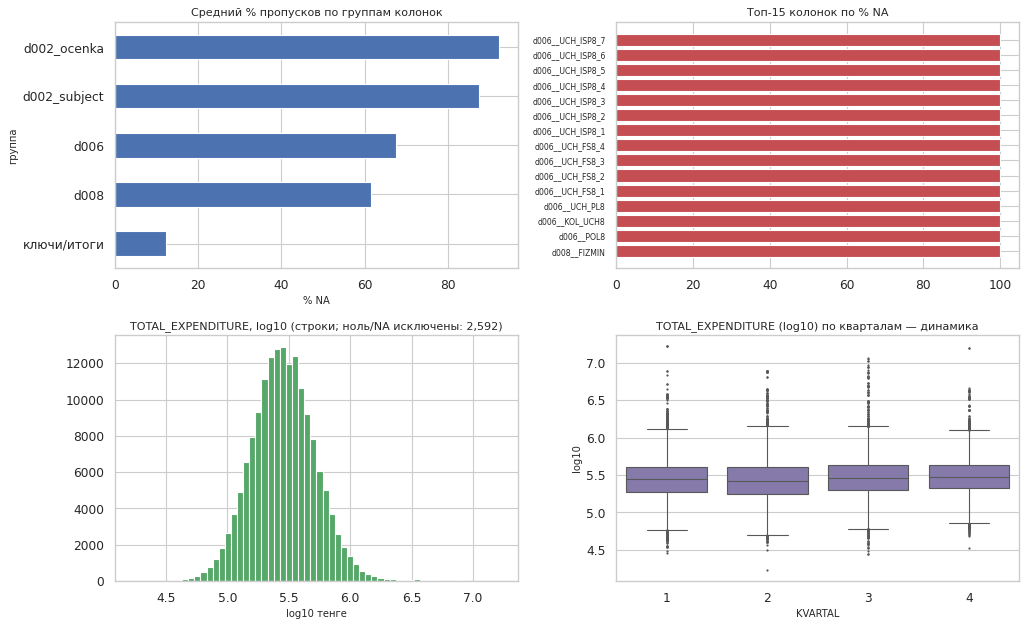

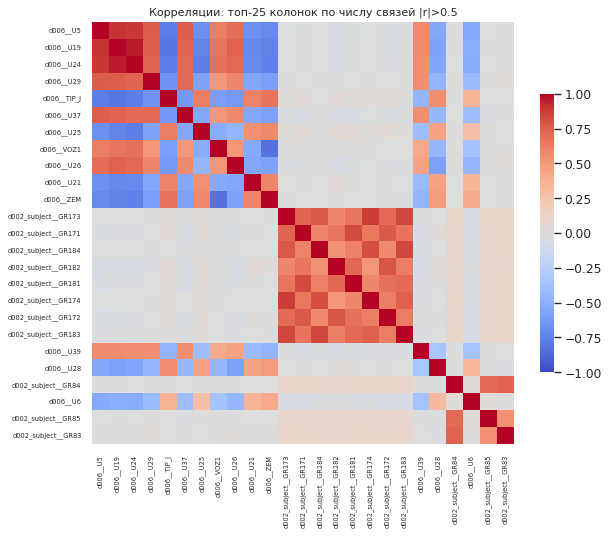

In [11]:
run_wide(2021)

**Выводы.** Ключ (HOUSEHOLD_ID, NOMP, KVARTAL) уникален, полных дубликатов нет; 12 000 домохозяйств, кварталы равномерны. Из 510 колонок 190 пусты полностью, 70 константны, блок D002 заполнен лишь в ~28,5% строк. `TOTAL_EXPENDITURE` повторяется по лицам одного домохозяйства — для анализа расходов агрегировать до домохозяйство×квартал.

## master_wide_2022.csv

Файл: 147 МБ (чтение чанками, тип float32 для дробных)


#### 1. Форма, типы, память

shape = 170,724 × 510; память ≈ 327 МБ; типы: {'float32': 495, 'int8': 9, 'int16': 4, 'int32': 1, 'float64': 1}


#### 2. Пропуски (только колонки с NA > 0)

...

,a,b,r
0,d002_subject__VOZ,d002_ocenka__VOZ,1.000
1,d008__POL,d002_ocenka__POL,1.000
2,d008__POL,d002_subject__POL,1.000
3,d002_subject__POL,d002_ocenka__POL,1.000
4,d008__GOD_ROJD,d002_ocenka__VOZ,-1.000
5,d008__GOD_ROJD,d002_subject__VOZ,-1.000
6,d008__STATUS3,d008__STATUS4,0.960
7,d008__STATUS1,d008__STATUS2,0.957
8,d008__STATUS2,d008__STATUS3,0.955
9,d006__U19,d006__U24,0.947


#### 8. Проверки структуры и ключей (специфично для master_wide)

Домохозяйств: 12,000; пар (домохозяйство, лицо): 42,681; лиц на домохозяйство-квартал: среднее 3.56, макс 13
Домохозяйств, у которых TE/K меняются между строками: 0.0%
TOTAL_EXPENDITURE: пропусков 1.2%; значение одно на домохозяйство-квартал в 100.0% случаев (т.е. повторяется по лицам — показатель уровня домохозяйства)
Дубли-артефакты слияния (_x/_y): {'NOMER_x==NOMER_y': 0.8, 'NOMER_x NA%': 0.0, 'NOMER_y NA%': 1.7, 'GODO_x==GODO_y': 28.0, 'GODO_x NA%': 72.0, 'GODO_y NA%': 72.0, 'NOMER_x == YEAR*1e6+HOUSEHOLD_ID, %': 100.0}


,колонок,средний % NA,полностью пустых колонок,"% строк, где вся группа пуста"
группа,,,,
ключи/итоги,12,12.200,0,0.000
d008,30,54.900,5,0.000
d002_subject,108,88.900,65,72.000
d002_ocenka,116,91.900,58,72.000
d006,244,67.900,54,1.700


#### Графики

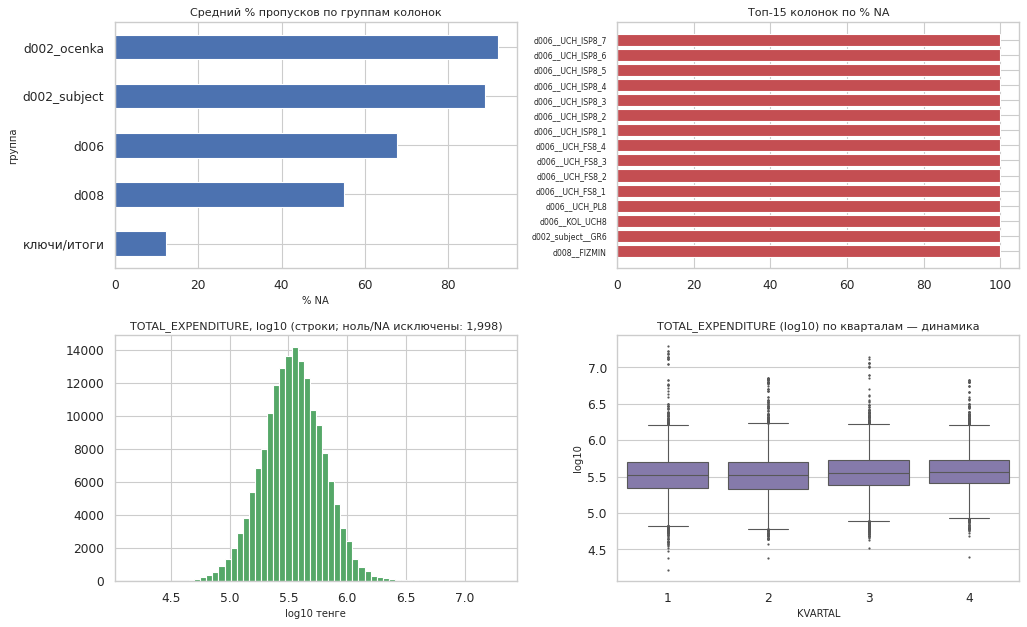

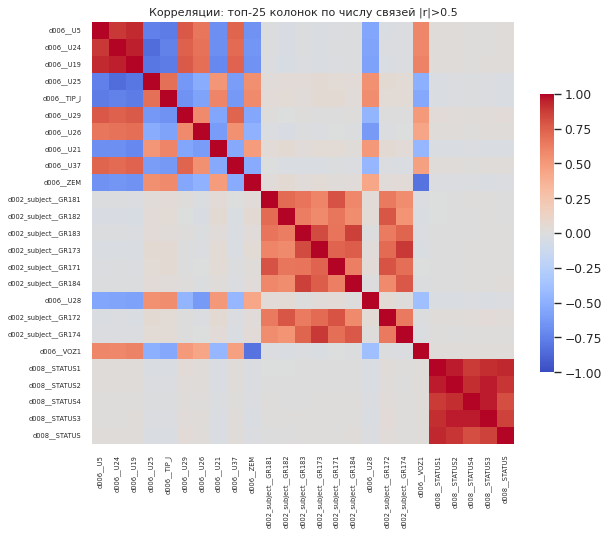

In [12]:
run_wide(2022)

**Выводы.** Структура та же: уникальный ключ, 12 000 домохозяйств, дубликатов нет. Пустых колонок 182, константных 89; D002 заполнен в ~28% строк. Число пар |r|>0.5 (154) сопоставимо с 2021, но часть из них — технические дубли колонок (|r|≥0.99: 6).

## master_wide_2023.csv

Файл: 148 МБ (чтение чанками, тип float32 для дробных)


#### 1. Форма, типы, память

shape = 170,756 × 510; память ≈ 328 МБ; типы: {'float32': 494, 'int8': 9, 'int16': 4, 'int32': 1, 'object': 1, 'float64': 1}


#### 2. Пропуски (только колонки с NA > 0)

...

,a,b,r
0,d002_subject__VOZ,d002_ocenka__VOZ,1.000
1,d008__POL,d002_ocenka__POL,1.000
2,d008__POL,d002_subject__POL,1.000
3,d002_subject__POL,d002_ocenka__POL,1.000
4,d008__GOD_ROJD,d002_ocenka__VOZ,-1.000
5,d008__GOD_ROJD,d002_subject__VOZ,-1.000
6,d008__STATUS1,d008__STATUS2,0.965
7,d008__STATUS2,d008__STATUS3,0.953
8,d006__U19,d006__U24,0.952
9,d008__STATUS,d008__STATUS1,0.947


#### 8. Проверки структуры и ключей (специфично для master_wide)

Домохозяйств: 12,000; пар (домохозяйство, лицо): 42,689; лиц на домохозяйство-квартал: среднее 3.56, макс 14
Домохозяйств, у которых TE/K меняются между строками: 0.0%
TOTAL_EXPENDITURE: пропусков 1.3%; значение одно на домохозяйство-квартал в 100.0% случаев (т.е. повторяется по лицам — показатель уровня домохозяйства)
Дубли-артефакты слияния (_x/_y): {'NOMER_x==NOMER_y': 0.7, 'NOMER_x NA%': 0.0, 'NOMER_y NA%': 2.6, 'GODO_x==GODO_y': 27.2, 'GODO_x NA%': 72.0, 'GODO_y NA%': 72.0, 'NOMER_x == YEAR*1e6+HOUSEHOLD_ID, %': 100.0}


,колонок,средний % NA,полностью пустых колонок,"% строк, где вся группа пуста"
группа,,,,
ключи/итоги,12,12.300,0,0.000
d008,30,57.600,7,0.000
d002_subject,108,86.700,39,72.000
d002_ocenka,116,90.500,27,72.000
d006,244,68.400,54,2.600


#### Графики

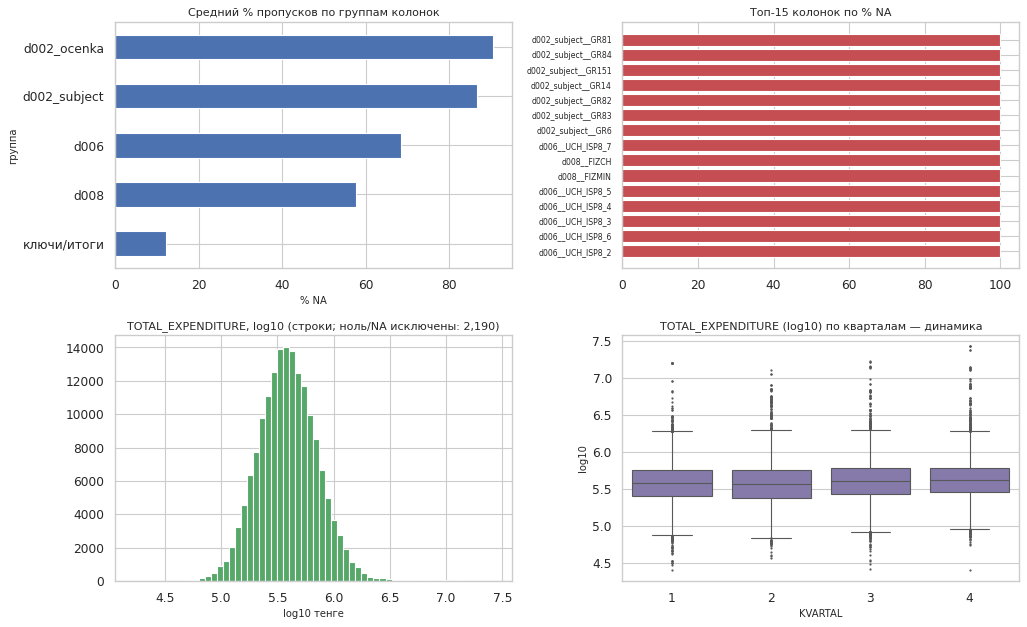

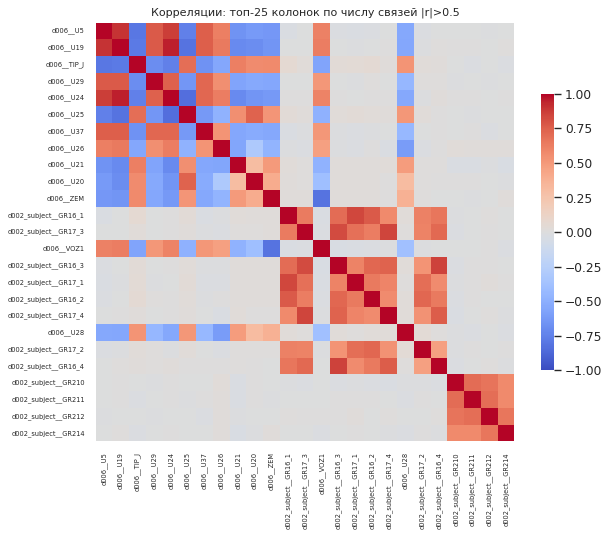

In [13]:
run_wide(2023)

**Выводы.** Пустых колонок заметно меньше (127), а кодированных стало больше (355 против 290 в 2021) — признак расширения формы опросника, а не «улучшения качества». Ключ по-прежнему уникален, дубликатов нет.

## master_wide_2024.csv

Файл: 147 МБ (чтение чанками, тип float32 для дробных)


#### 1. Форма, типы, память

shape = 167,284 × 510; память ≈ 321 МБ; типы: {'float32': 495, 'int8': 9, 'int16': 4, 'int32': 1, 'float64': 1}


#### 2. Пропуски (только колонки с NA > 0)

...

,a,b,r
0,d002_subject__VOZ,d002_ocenka__VOZ,1.000
1,d002_subject__POL,d002_ocenka__POL,1.000
2,d008__POL,d002_subject__POL,1.000
3,d008__POL,d002_ocenka__POL,1.000
4,d008__GOD_ROJD,d002_subject__VOZ,-1.000
5,d008__GOD_ROJD,d002_ocenka__VOZ,-1.000
6,d006__U19,d006__U24,0.983
7,d008__STATUS3,d008__STATUS4,0.971
8,d008__STATUS1,d008__STATUS2,0.965
9,d008__STATUS2,d008__STATUS3,0.957


#### 8. Проверки структуры и ключей (специфично для master_wide)

Домохозяйств: 12,000; пар (домохозяйство, лицо): 41,821; лиц на домохозяйство-квартал: среднее 3.49, макс 12
Домохозяйств, у которых TE/K меняются между строками: 0.0%
TOTAL_EXPENDITURE: пропусков 1.3%; значение одно на домохозяйство-квартал в 100.0% случаев (т.е. повторяется по лицам — показатель уровня домохозяйства)
Дубли-артефакты слияния (_x/_y): {'NOMER_x==NOMER_y': 0.8, 'NOMER_x NA%': 0.0, 'NOMER_y NA%': 2.2, 'GODO_x==GODO_y': 28.5, 'GODO_x NA%': 71.5, 'GODO_y NA%': 71.5, 'NOMER_x == YEAR*1e6+HOUSEHOLD_ID, %': 100.0}


,колонок,средний % NA,полностью пустых колонок,"% строк, где вся группа пуста"
группа,,,,
ключи/итоги,12,12.200,0,0.000
d008,30,47.600,1,0.000
d002_subject,108,86.500,41,71.500
d002_ocenka,116,90.500,28,71.500
d006,244,67.700,56,2.200


#### Графики

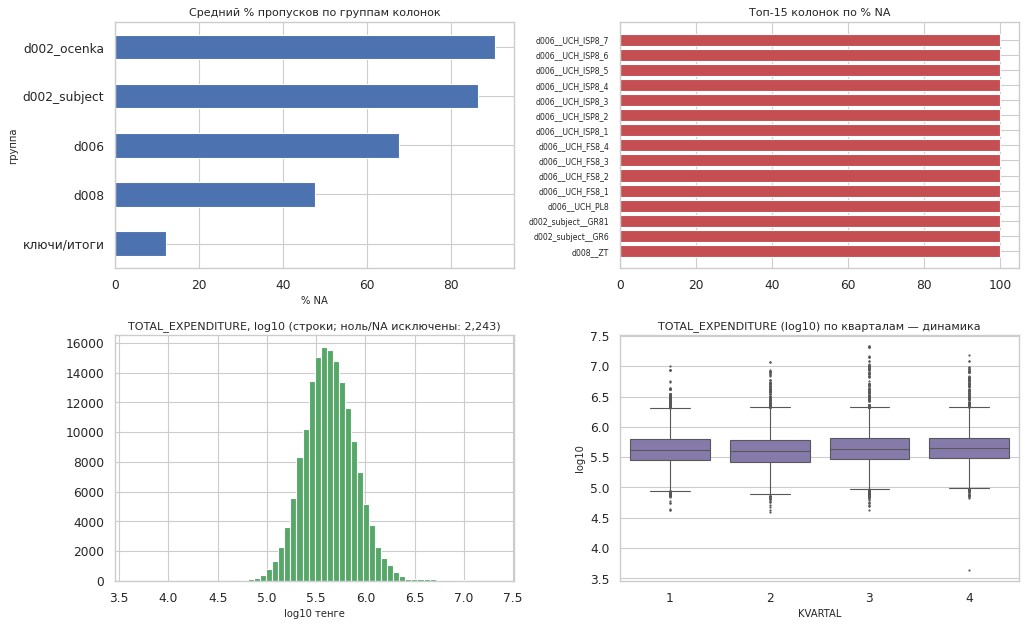

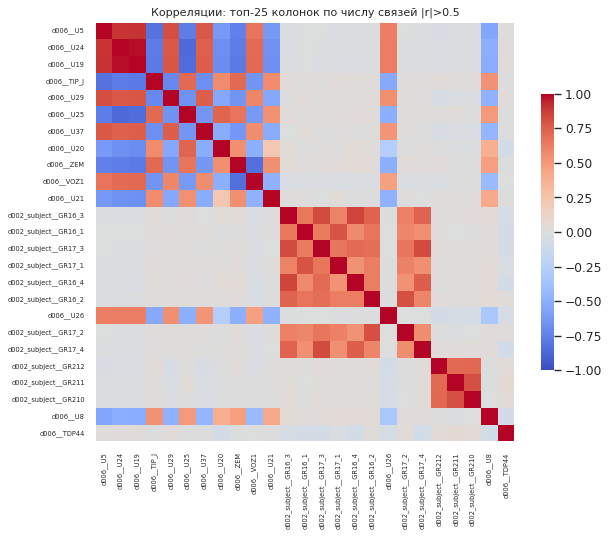

In [14]:
run_wide(2024)

**Выводы.** Пустых колонок 126, константных 94; средний % NA в блоке D008 ниже (47,6% против 61,5% в 2021). Пар |r|>0.5 стало больше (197) — сверять с формой опросника, т.к. смысл колонок мог измениться.

## Сравнение годов master_wide (схема и «смысл» колонок)
Имена колонок одинаковы во всех годах (510), поэтому сравниваем не набор имён, а **заполненность** и **набор значений** по годам: резкие расхождения — кандидаты на изменение формы опросника.

Колонок в годах: {2021: 510, 2022: 510, 2023: 510, 2024: 510} | общих имён: 510


,колонок,разброс %NA между годами >50 п.п.,пусты (100%) не во всех годах
d002_ocenka,116,0,93
d002_subject,108,0,95
d006,244,0,30
d008,30,5,8
ключи/итоги,12,0,0


,2021,2022,2023,2024,разброс,расшифровка
d008__GOD_ROJD,100.000,0.000,0.000,0.000,100.000,год рождения
d008__FIZMIN,100.000,100.000,100.000,0.000,100.000,
d008__MES_ROJD,100.000,0.000,0.000,0.000,100.000,месяц рождения
d008__FIZ,100.000,100.000,100.000,3.400,96.600,
d008__STATUS4,30.000,30.000,100.000,30.000,70.000,


Колонок с кодированными значениями (≤30 уник.), у которых набор значений резко меняется между годами (Jaccard<0.6): 56


,колонка,мин. Jaccard соседних лет,значения по годам,расшифровка
49,d006__TDP32,0.000,"[np.float32(1.0), np.float32 | [np.float32(1.0), np.float32 | ['.'...",
39,d006__NOMP7,0.000,"[np.float32(7.0)] | [np.float32(7.0)] | [np.float32(10.0), np.floa...",
41,d006__VOZ7,0.140,"[np.float32(0.0), np.float32 | [np.float32(0.0), np.float32 | [np....",
38,d006__UCH_PL6,0.200,"[np.float32(6.0)] | [np.float32(6.0), np.float32 | [np.float32(4.0...",
6,d002_ocenka__GR317,0.220,"[np.float32(1.0), np.float32 | [np.float32(1.0), np.float32 | [np....",3 часть вопрос 17 [2023]
14,d006__KOLNJ4,0.330,"[np.float32(1.0), np.float32 | [np.float32(1.0), np.float32 | [np....",
35,d006__UCH_PL5,0.380,"[np.float32(6.0), np.float32 | [np.float32(5.0), np.float32 | [np....",
29,d006__UCH_PL3,0.390,"[np.float32(2.0), np.float32 | [np.float32(2.0), np.float32 | [np....",
45,d006__TDP11,0.400,"[np.float32(1.0), np.float32 | [np.float32(1.0), np.float32 | [np....",
36,d006__NOMP6,0.400,"[np.float32(6.0), np.float32 | [np.float32(6.0), np.float32 | [np....",


По группам: {'d006': 47, 'd002_ocenka': 5, 'd008': 3, 'd002_subject': 1}


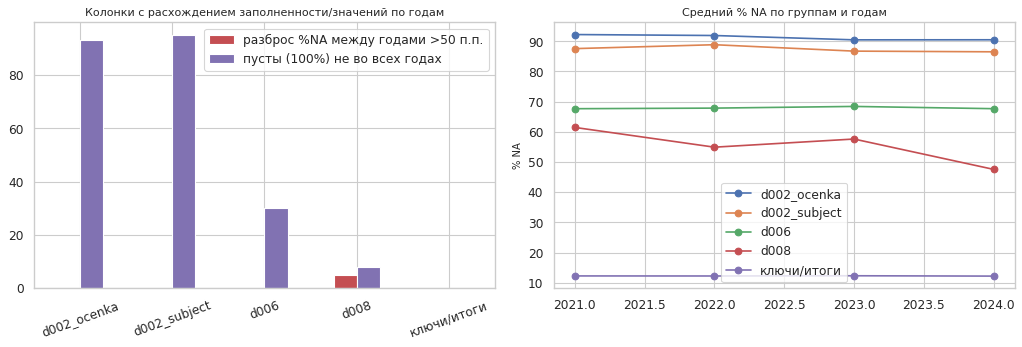

In [15]:
NA = pd.DataFrame(NAPCT); yrs = list(NA.columns)
print('Колонок в годах:', {y: len(NAPCT[y]) for y in yrs}, '| общих имён:', len(set.intersection(*[set(NAPCT[y].index) for y in yrs])))
spread = NA.max(axis=1) - NA.min(axis=1); flag = spread[spread > 50].index
empty_some = NA.index[(NA.eq(100).sum(axis=1) > 0) & (NA.eq(100).sum(axis=1) < len(yrs))]
G = pd.Series([grp(c) for c in NA.index], index=NA.index)
summary = pd.DataFrame({'колонок': G.value_counts(), 'разброс %NA между годами >50 п.п.': G[flag].value_counts(), 'пусты (100%) не во всех годах': G[empty_some].value_counts()}).fillna(0).astype(int); display(summary)
top = NA.loc[flag].assign(разброс=spread[flag]).sort_values('разброс', ascending=False).head(20); top['расшифровка'] = [lab(c) for c in top.index]; display(top.round(1))
rows = []
for c in NA.index:
    sets = [VALSET[y].get(c) for y in yrs]; js = []
    for a, b in zip(sets[:-1], sets[1:]):
        if a and b and (len(a) > 1 or len(b) > 1): js.append(len(a & b) / len(a | b))
    if js and min(js) < 0.6: rows.append({'колонка': c, 'мин. Jaccard соседних лет': round(min(js), 2), 'значения по годам': ' | '.join(str(sorted(s))[:28] if s else '—' for s in sets), 'расшифровка': lab(c)})
J = pd.DataFrame(rows).sort_values('мин. Jaccard соседних лет') if rows else pd.DataFrame()
print(f'Колонок с кодированными значениями (≤30 уник.), у которых набор значений резко меняется между годами (Jaccard<0.6): {len(J)}')
if len(J): display(J.head(20)); print('По группам:', J.колонка.map(grp).value_counts().to_dict())
FACTS['cross_year'] = {'flag_na_spread_gt50': int(len(flag)), 'empty_some_years': int(len(empty_some)), 'by_group_flag': G[flag].value_counts().to_dict(), 'jaccard_lt_06': int(len(J)), 'jaccard_by_group': J.колонка.map(grp).value_counts().to_dict() if len(J) else {}}
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
summary.iloc[:, 1:].plot.bar(ax=ax[0], color=['#c44e52', '#8172b2']); ax[0].set_title('Колонки с расхождением заполненности/значений по годам'); ax[0].tick_params(axis='x', rotation=20)
gm = NA.groupby(G).mean().T; gm.plot(marker='o', ax=ax[1]); ax[1].set_title('Средний % NA по группам и годам'); ax[1].set_ylabel('% NA'); plt.tight_layout(); plt.show()

**Выводы.** Имена колонок идентичны (510), но 226 колонок пусты лишь в части лет, а у 56 кодированных колонок набор значений резко меняется между соседними годами (47 из них — D006). Сопоставлять колонки по имени без кодбука по годам нельзя.

# Часть B. D004 — 12 частей опросника (kv_vopr)
Длинный формат; `NOMER` = год×10⁶ + номер домохозяйства (гипотеза, проверяется в блоках ниже и в разделе связей).

## D004 · kv_vopr_0_combined.csv

Файл: 5 МБ


,колонка,"расшифровка (структура D004, 2022)"
0,TE,Код территории
1,K,Код местности
2,NOMER,код домохозяйства
3,REZ,Код результата посещения
4,KVARTAL,Номер квартала
5,GOD,Год


#### 1. Форма, типы, память

shape = 192,000 × 6; память ≈ 2 МБ; типы: {'int8': 4, 'int16': 1, 'int32': 1}


...

Время: 2021–2024, гранулярность — квартал (календарных дат нет); пропусков в GOD/KVARTAL: 0; пустые ячейки год×квартал: нет


квартал,1,2,3,4
год,,,,
2021,12000,12000,12000,12000
2022,12000,12000,12000,12000
2023,12000,12000,12000,12000
2024,12000,12000,12000,12000


#### 7. Корреляции

Корреляции: недостаточно числовых колонок
Нормализация ключа домохозяйства: NOMER − GOD·10⁶ даёт значение в диапазоне 1..99999 в 100.0% строк; уникальных (год, домохозяйство): 48,000


#### Графики

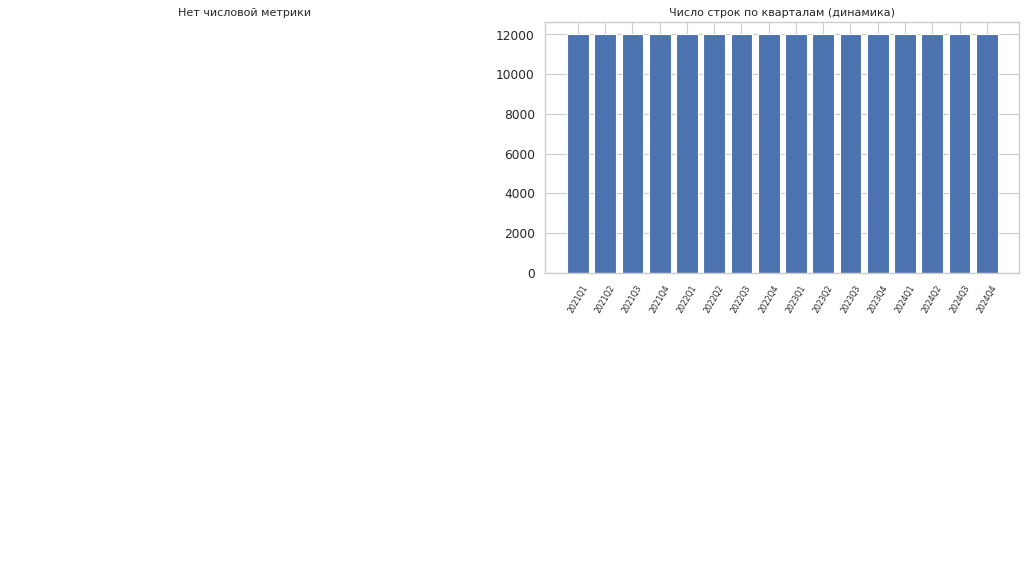

In [16]:
run_kv(0)

**Выводы.** Контрольная карточка: 192 000 строк = 48 000 домохозяйство-лет × 4 квартала, без пропусков и дубликатов, все 16 кварталов 2021–2024 есть. Годится как опорная таблица для join'ов.

## D004 · kv_vopr_1_combined.csv

Файл: 175 МБ (>50 МБ: чтение чанками, профиль по выборке)


,колонка,"расшифровка (структура D004, 2022)"
0,TE,Код территории
1,K,Код местности
2,NOMER,код домохозяйства
3,KODNU,Код товара
4,CELPOK,Цель покупки
5,STOIMK,Стоимость
6,KVARTAL,Номер квартала
7,GOD,Год


#### 1. Форма, типы, память

shape = 4,391,820 × 10; память ≈ 109 МБ; типы: {'int8': 4, 'int32': 3, 'float32': 2, 'int16': 1}


...

Время: 2021–2024, гранулярность — квартал (календарных дат нет); пропусков в GOD/KVARTAL: 0; пустые ячейки год×квартал: нет


квартал,1,2,3,4
год,,,,
2021,268143,274850,291409,258042
2022,270907,274264,297560,262008
2023,267827,267699,298072,265988
2024,269130,267326,294179,264416


#### 7. Корреляции

Корреляции: недостаточно числовых колонок
Нормализация ключа домохозяйства: NOMER − GOD·10⁶ даёт значение в диапазоне 1..99999 в 100.0% строк; уникальных (год, домохозяйство): 47,810


#### Графики

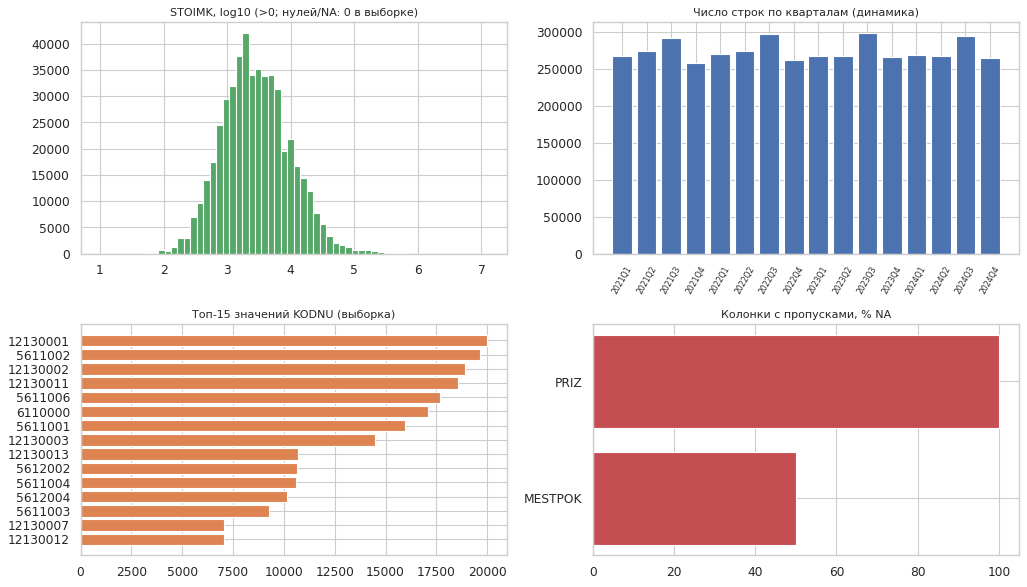

In [17]:
run_kv(1)

**Выводы.** 4,39 млн строк; `PRIZ` пуст на 100%, `MESTPOK` — на 50%; 17 607 полных дубликатов (0,4%). Ключ (NOMER, KVARTAL, KODNU, …) не уникален (~673 тыс. повторов) — вероятно, несколько записей на позицию, ключ нужно уточнить. `STOIMK` сильно скошена вправо.

## D004 · kv_vopr_2_combined.csv

Файл: 42 МБ


,колонка,"расшифровка (структура D004, 2022)"
0,TE,Код территории
1,K,Код местности
2,NOMER,код домохозяйства
4,KODNU,Код товара
6,STOIMK,Стоимость
7,KVARTAL,Номер квартала
8,GOD,Год


#### 1. Форма, типы, память

shape = 998,776 × 9; память ≈ 21 МБ; типы: {'int8': 4, 'float32': 2, 'int32': 2, 'int16': 1}


...

Время: 2021–2024, гранулярность — квартал (календарных дат нет); пропусков в GOD/KVARTAL: 0; пустые ячейки год×квартал: нет


квартал,1,2,3,4
год,,,,
2021,63983,62989,59264,64216
2022,63392,61482,58844,63636
2023,64324,62744,58679,63803
2024,65466,62559,58974,64421


#### 7. Корреляции

Корреляции: недостаточно числовых колонок
Нормализация ключа домохозяйства: NOMER − GOD·10⁶ даёт значение в диапазоне 1..99999 в 100.0% строк; уникальных (год, домохозяйство): 47,823


#### Графики

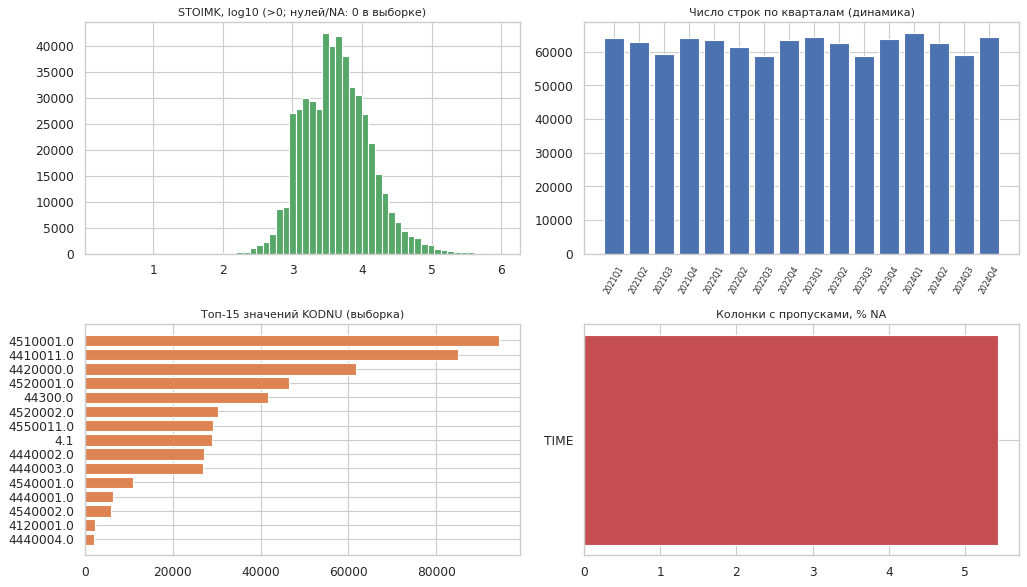

In [18]:
run_kv(2)

**Выводы.** ~1,0 млн строк, пропуски только в `TIME` (5,4%); 1 456 полных дубликатов. `STOIMK` правосторонняя, ~9% выбросов по IQR (в выборке).

## D004 · kv_vopr_3_combined.csv

Файл: 16 МБ


,колонка,"расшифровка (структура D004, 2022)"
0,TE,Код территории
1,K,Код местности
2,NOMER,код домохозяйства
3,KODNU,Код товара
4,NOMVOPR,Номер вопроса
6,STOIMK,Стоимость
7,KVARTAL,Номер квартала
8,GOD,Год


#### 1. Форма, типы, память

shape = 422,130 × 8; память ≈ 7 МБ; типы: {'int8': 4, 'int32': 3, 'int16': 1}


...

Время: 2021–2024, гранулярность — квартал (календарных дат нет); пропусков в GOD/KVARTAL: 0; пустые ячейки год×квартал: нет


квартал,1,2,3,4
год,,,,
2021,26787,26496,26224,26251
2022,27068,27272,26662,26760
2023,27403,26927,26506,26110
2024,26191,25476,25350,24647


#### 7. Корреляции

Корреляции: недостаточно числовых колонок
Нормализация ключа домохозяйства: NOMER − GOD·10⁶ даёт значение в диапазоне 1..99999 в 100.0% строк; уникальных (год, домохозяйство): 47,811


#### Графики

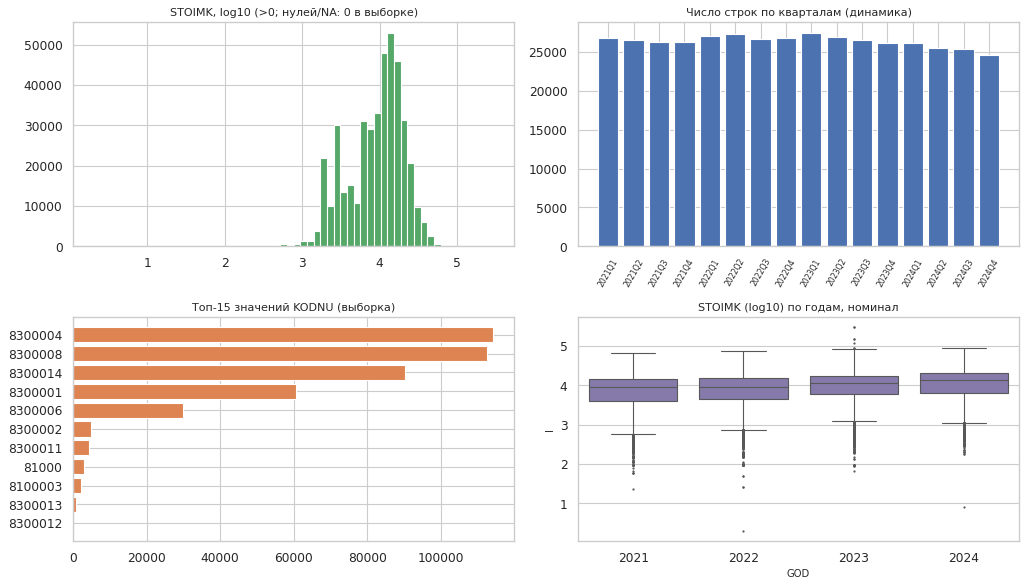

In [19]:
run_kv(3)

**Выводы.** 423 тыс. строк, пропусков нет; 1 329 полных дубликатов (0,3%). Охват по кварталам ровный (min/max ≈0,9).

## D004 · kv_vopr_4_combined.csv

Файл: 1 МБ


,колонка,"расшифровка (структура D004, 2022)"
0,TE,Код территории
1,K,Код местности
2,NOMER,код домохозяйства
3,KODNU,Код товара
4,NOMVOPR,Номер вопроса
5,STOIMK,Стоимость
6,KVARTAL,Номер квартала
7,GOD,Год


#### 1. Форма, типы, память

shape = 37,119 × 8; память ≈ 1 МБ; типы: {'int8': 4, 'int32': 3, 'int16': 1}


...

Время: 2021–2024, гранулярность — квартал (календарных дат нет); пропусков в GOD/KVARTAL: 0; пустые ячейки год×квартал: нет


квартал,1,2,3,4
год,,,,
2021,1737,1595,1651,1897
2022,2583,2190,2163,2369
2023,3018,2611,2540,2585
2024,2843,2490,2261,2586


#### 7. Корреляции

Корреляции: недостаточно числовых колонок
Нормализация ключа домохозяйства: NOMER − GOD·10⁶ даёт значение в диапазоне 1..99999 в 100.0% строк; уникальных (год, домохозяйство): 13,454


#### Графики

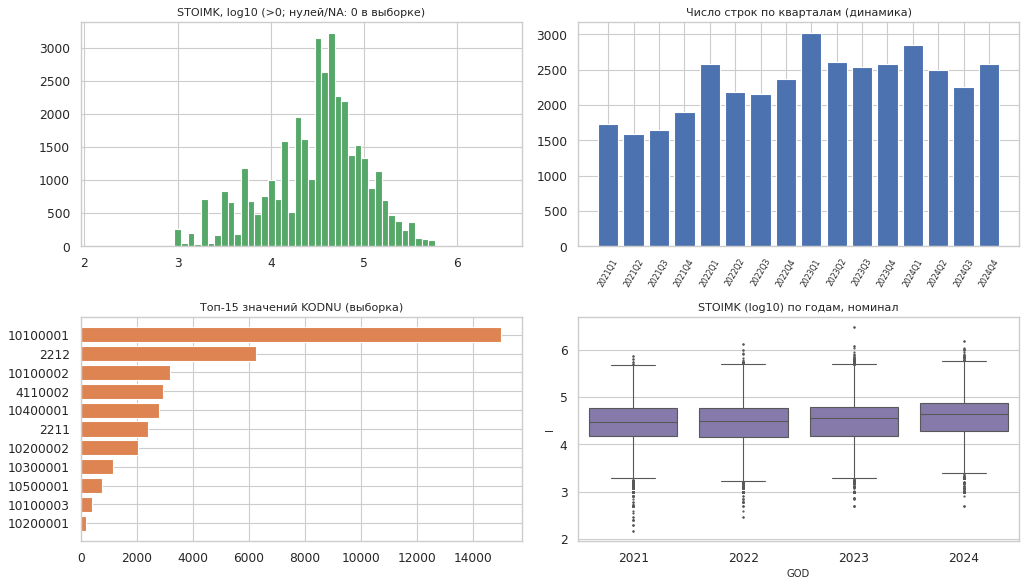

In [20]:
run_kv(4)

**Выводы.** Малая часть: 37 тыс. строк и лишь ~13,5 тыс. домохозяйств из 48 тыс.; заметная неравномерность по кварталам (min/max ≈0,53). Дубликаты: 61 полный.

## D004 · kv_vopr_5_combined.csv

Файл: 3 МБ


,колонка,"расшифровка (структура D004, 2022)"
0,TE,Код территории
1,K,Код местности
2,NOMER,код домохозяйства
3,KODNU,Код товара
4,NOMVOPR,Номер вопроса
5,STOIMK,Стоимость
6,KVARTAL,Номер квартала
7,GOD,Год


#### 1. Форма, типы, память

shape = 74,202 × 8; память ≈ 1 МБ; типы: {'int8': 4, 'int32': 3, 'int16': 1}


...

Время: 2021–2024, гранулярность — квартал (календарных дат нет); пропусков в GOD/KVARTAL: 0; пустые ячейки год×квартал: нет


квартал,1,2,3,4
год,,,,
2021,5270,5032,5062,4577
2022,4361,5146,4693,4350
2023,4398,4554,4792,4325
2024,4511,4673,4295,4163


#### 7. Корреляции

Корреляции: недостаточно числовых колонок
Нормализация ключа домохозяйства: NOMER − GOD·10⁶ даёт значение в диапазоне 1..99999 в 100.0% строк; уникальных (год, домохозяйство): 27,510


#### Графики

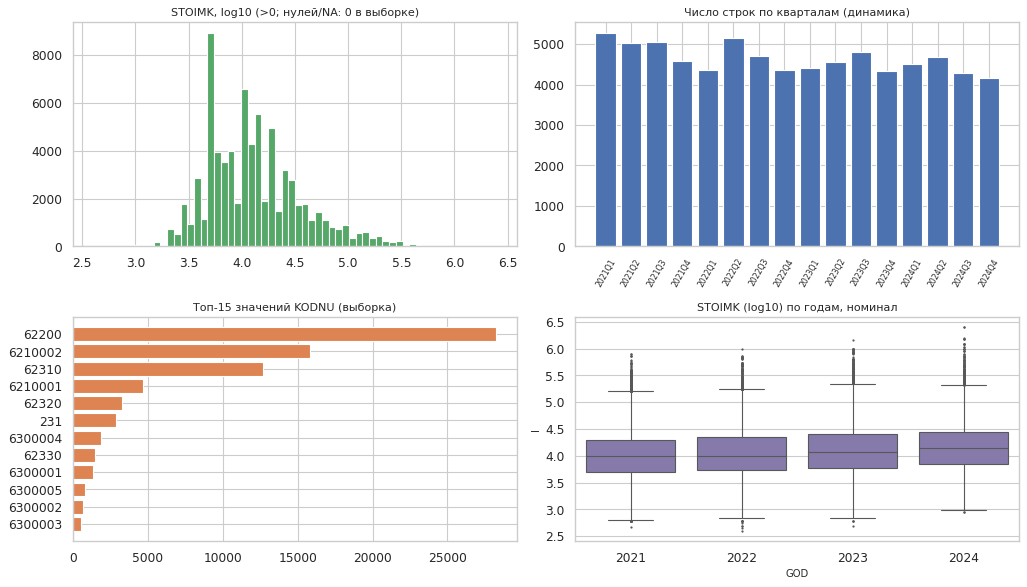

In [21]:
run_kv(5)

**Выводы.** 74 тыс. строк, ~27,5 тыс. домохозяйств (не все домохозяйства имеют записи); пропусков нет, 222 полных дубликата.

## D004 · kv_vopr_6_combined.csv

Файл: 28 МБ


,колонка,"расшифровка (структура D004, 2022)"
0,TE,Код территории
1,K,Код местности
2,NOMER,код домохозяйства
3,KODNU,Код товара
4,NOMVOPR,Номер вопроса
5,NOMOTV,Номер ответа
6,STOIMK,Стоимость
7,KVARTAL,Номер квартала
8,GOD,Год


#### 1. Форма, типы, память

shape = 675,523 × 10; память ≈ 17 МБ; типы: {'int8': 4, 'int32': 3, 'float32': 2, 'int16': 1}


...

Время: 2021–2024, гранулярность — квартал (календарных дат нет); пропусков в GOD/KVARTAL: 0; пустые ячейки год×квартал: нет


квартал,1,2,3,4
год,,,,
2021,36743,38414,41746,37212
2022,39345,40721,46226,40246
2023,42121,42588,48622,42837
2024,44054,44266,46988,43394


#### 7. Корреляции

Корреляции: недостаточно числовых колонок
Нормализация ключа домохозяйства: NOMER − GOD·10⁶ даёт значение в диапазоне 1..99999 в 100.0% строк; уникальных (год, домохозяйство): 47,658


#### Графики

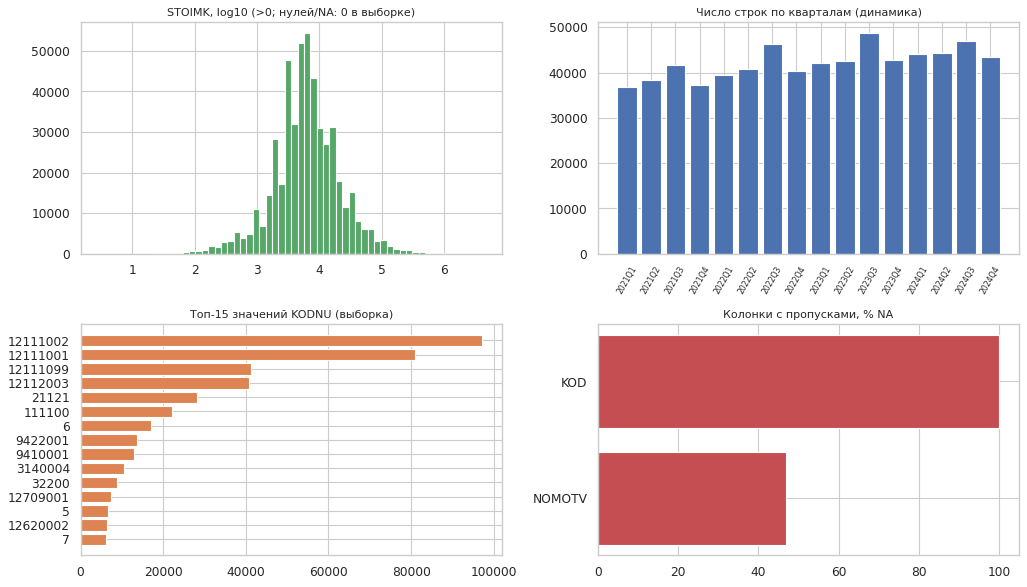

In [22]:
run_kv(6)

**Выводы.** `KOD` пуст на 100%, `NOMOTV` — на 47%; 4 046 полных дубликатов. Колонку `KOD` можно исключить из анализа.

## D004 · kv_vopr_7_combined.csv

Файл: 9 МБ


,колонка,"расшифровка (структура D004, 2022)"
0,TE,Код территории
1,K,Код местности
2,NOMER,код домохозяйства
3,KODNU,Код товара
4,NOMVOPR,Номер вопроса
5,STOIMK,Стоимость
6,KVARTAL,Номер квартала
7,GOD,Год


#### 1. Форма, типы, память

shape = 248,753 × 8; память ≈ 4 МБ; типы: {'int8': 4, 'int32': 3, 'int16': 1}


...

Время: 2021–2024, гранулярность — квартал (календарных дат нет); пропусков в GOD/KVARTAL: 0; пустые ячейки год×квартал: нет


квартал,1,2,3,4
год,,,,
2021,14330,14451,14734,14110
2022,15010,15382,15607,15263
2023,15573,15848,16583,16154
2024,16355,16645,16576,16132


#### 7. Корреляции

Корреляции: недостаточно числовых колонок
Нормализация ключа домохозяйства: NOMER − GOD·10⁶ даёт значение в диапазоне 1..99999 в 100.0% строк; уникальных (год, домохозяйство): 44,075


#### Графики

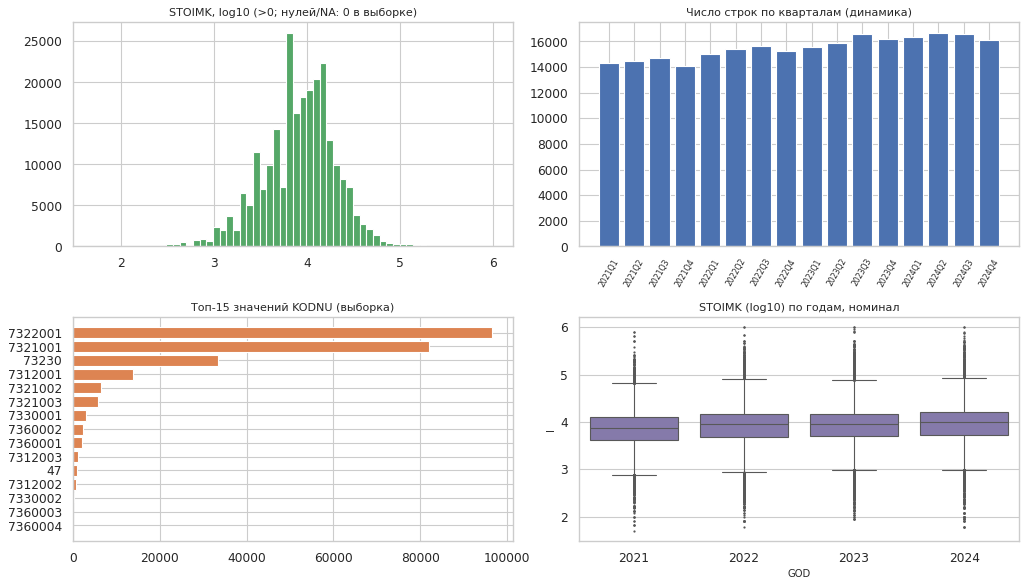

In [23]:
run_kv(7)

**Выводы.** 249 тыс. строк, ~44 тыс. домохозяйств; пропусков нет, 573 полных дубликата. Статистика `STOIMK` — как в других «денежных» частях: правая асимметрия.

## D004 · kv_vopr_9_combined.csv

Файл: 57 МБ (>50 МБ: чтение чанками, профиль по выборке)


,колонка,"расшифровка (структура D004, 2022)"
0,TE,Код территории
1,K,Код местности
2,NOMER,код домохозяйства
3,KODNU,Код товара
4,NOMVOPR,Номер вопроса
5,NOMOTV,Номер ответа
6,GR7,Графа 7
7,GR8,Графа 8 (В бланке Д004 гр.2-гр.9)
8,KVARTAL,Номер квартала
9,PRICE,Средняя цена


#### 1. Форма, типы, память

shape = 917,692 × 20; память ≈ 59 МБ; типы: {'float32': 14, 'int8': 3, 'int16': 2, 'int32': 1}


...

#### 7. Корреляции

Корреляции (Pearson, выборка 20,000 строк, 10 колонок): пар с |r|>0.5 — 2, из них |r|≥0.99 — 0


,a,b,r
0,GR5,GR7,0.510
1,GR8,PRICE,0.508


Нормализация ключа домохозяйства: NOMER − GOD·10⁶ даёт значение в диапазоне 1..99999 в 100.0% строк; уникальных (год, домохозяйство): 47,824


#### Графики

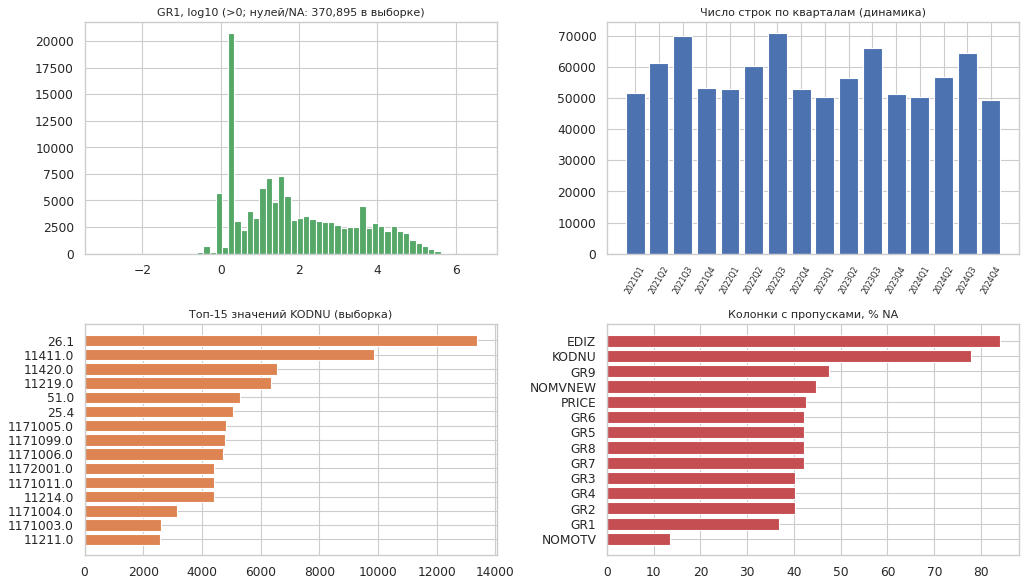

In [24]:
run_kv(9)

**Выводы.** Самая «дырявая» часть: 14 из 20 колонок с пропусками (`EDIZ` 84%, `KODNU` 78%), 19 073 полных дубликата (2,1% — максимум среди частей); 8 из 10 числовых колонок имеют IQR=0 (разреженные). Кварталы неравномерны (min/max ≈0,7).

## D004 · kv_vopr_10_combined.csv

Файл: 9 МБ


,колонка,"расшифровка (структура D004, 2022)"
0,TE,Код территории
1,K,Код местности
2,NOMER,код домохозяйства
3,KODNU,Код товара
4,NOMVOPR,Номер вопроса
5,GR1,Стоимость
6,GR2,Сумма продажи
7,GR3,Сумма продано продукции произведенной ранее
8,GR4,Оценка затрат на производство
9,KVARTAL,Номер квартала


#### 1. Форма, типы, память

shape = 166,793 × 12; память ≈ 6 МБ; типы: {'float32': 4, 'int8': 3, 'int32': 3, 'int16': 2}


...

#### 7. Корреляции

Корреляции (Pearson, выборка 20,000 строк, 4 колонок): пар с |r|>0.5 — 1, из них |r|≥0.99 — 0


,a,b,r
0,GR1,GR2,0.718


Нормализация ключа домохозяйства: NOMER − GOD·10⁶ даёт значение в диапазоне 1..99999 в 100.0% строк; уникальных (год, домохозяйство): 29,759


#### Графики

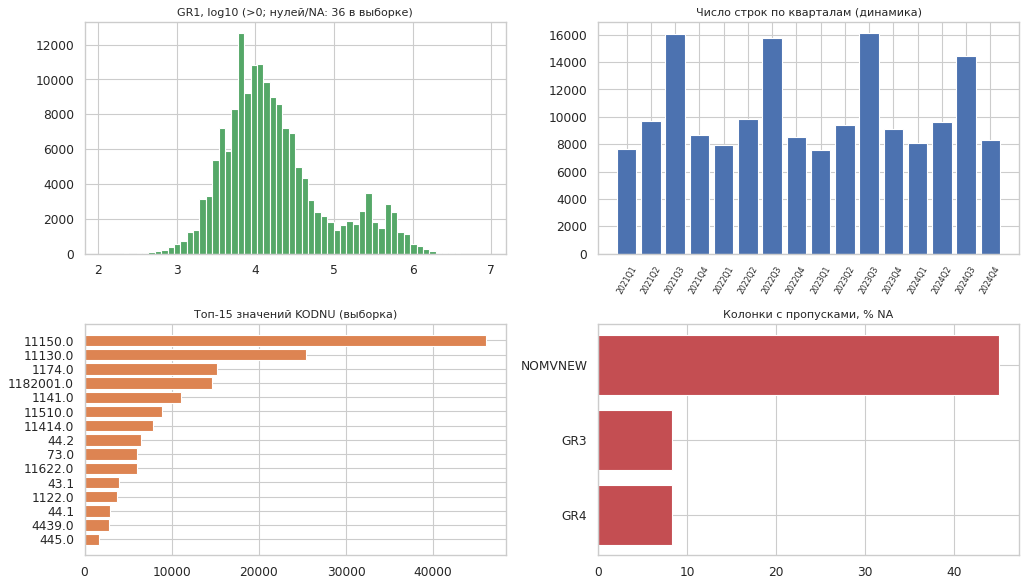

In [25]:
run_kv(10)

**Выводы.** 167 тыс. строк, `NOMVNEW` пуст на 45%, `GR3`/`GR4` — на 8,3%. Самая неравномерная часть по кварталам (min/max ≈0,47) — проверить сезонность и полноту сбора.

## D004 · kv_vopr_11_combined.csv

Файл: 35 МБ


,колонка,"расшифровка (структура D004, 2022)"
0,TE,Код территории
1,K,Код местности
2,NOMER,код домохозяйства
3,NOMP,Номер члена домохоз-ва
4,VOZ,Возраст члена домохоз-ва
5,POL,Пол члена домохоз-ва
6,NOMVOPR,Номер вопроса
7,KVARTAL,Номер квартала
8,GOD,Год


#### 1. Форма, типы, память

shape = 396,510 × 33; память ≈ 42 МБ; типы: {'int32': 24, 'int8': 6, 'int16': 2, 'float32': 1}


...

#### 7. Корреляции

Корреляции (Pearson, выборка 20,000 строк, 24 колонок): пар с |r|>0.5 — 1, из них |r|≥0.99 — 0


,a,b,r
0,VOZ,GR4,0.668


Нормализация ключа домохозяйства: NOMER − GOD·10⁶ даёт значение в диапазоне 1..99999 в 100.0% строк; уникальных (год, домохозяйство): 47,768


#### Графики

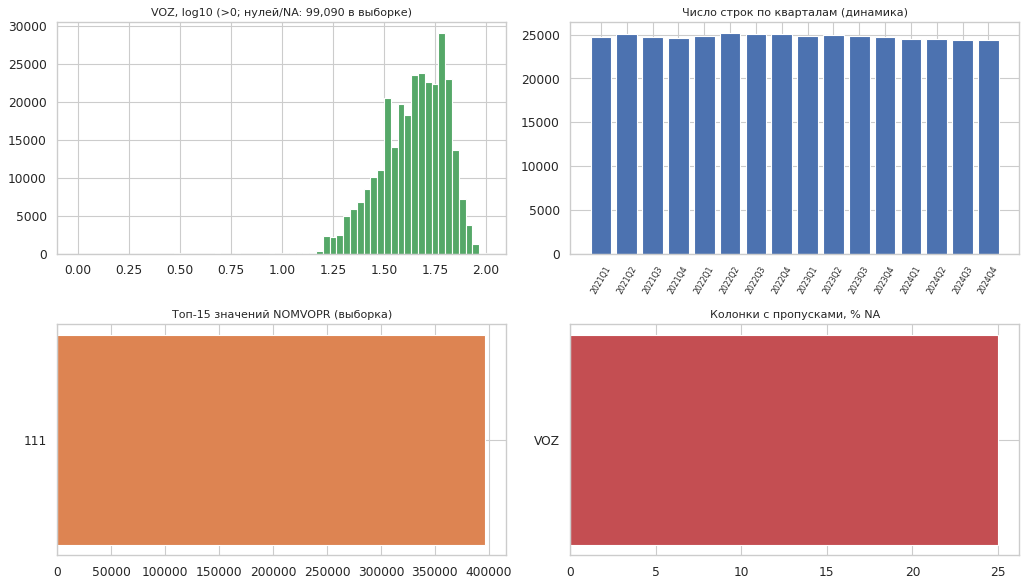

In [26]:
run_kv(11)

**Выводы.** Уровень лиц (`NOMP`, `VOZ`, `POL`): 397 тыс. строк, дубликатов нет, `VOZ` пуст на 25%. Большинство из 24 числовых колонок разрежены (21 с IQR=0), корреляции малоинформативны.

## D004 · kv_vopr_12_combined.csv

Файл: 4 МБ


,колонка,"расшифровка (структура D004, 2022)"
0,TE,Код территории
1,K,Код местности
2,NOMER,код домохозяйства
3,KODNU,Наименование видов расходов
4,KOD,Коды ответов для вопросов 2.1 и 2.2
5,NOMVNEW,"Номер вопроса (20,21,22) –"
6,STOIMK,"Сумма за квартал, тенге"
7,KVARTAL,Номер квартала
8,GOD,Год


#### 1. Форма, типы, память

shape = 91,166 × 12; память ≈ 3 МБ; типы: {'float32': 5, 'int8': 4, 'object': 1, 'int16': 1, 'int32': 1}


...

Время: 2021–2024, гранулярность — квартал (календарных дат нет); пропусков в GOD/KVARTAL: 0; пустые ячейки год×квартал: нет


квартал,1,2,3,4
год,,,,
2021,5601,4972,5193,4633
2022,5692,5243,6366,4937
2023,6063,5962,5893,5657
2024,6882,6330,6131,5611


#### 7. Корреляции

Корреляции: недостаточно числовых колонок
Нормализация ключа домохозяйства: NOMER − GOD·10⁶ даёт значение в диапазоне 1..99999 в 100.0% строк; уникальных (год, домохозяйство): 21,166


#### Графики

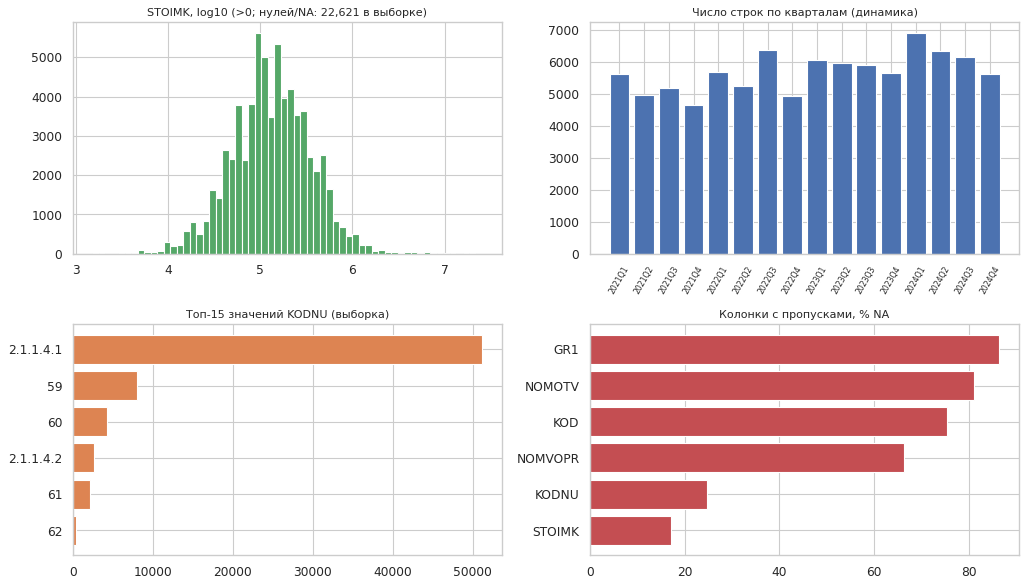

In [27]:
run_kv(12)

**Выводы.** Заёмные средства: 91 тыс. строк, много пропусков в идентифицирующих полях (`GR1` 86%, `NOMOTV` 81%, `KOD` 75%, `NOMVOPR` 66%) — вероятно, в одной таблице смешаны разные типы записей; нужен кодбук.

# Часть C. Связи между датасетами
Ключи: `HOUSEHOLD_ID` (master_wide) ↔ `NOMER − GOD·10⁶` (D004); лицо: `NOMP`; территория: `TE`, `K`.

**Доля домохозяйств master_wide, присутствующих в каждой части D004, %**

год,2021,2022,2023,2024
часть,,,,
0,100.000,100.000,100.000,100.000
1,99.600,99.500,99.700,99.700
2,99.600,99.500,99.800,99.700
3,99.600,99.500,99.700,99.700
4,23.100,28.500,30.700,29.900
5,57.300,57.500,57.900,56.500
6,99.300,98.900,99.500,99.400
7,90.200,91.000,92.500,93.500
9,99.600,99.500,99.800,99.700


**Доля домохозяйств части D004, найденных в master_wide, %**

год,2021,2022,2023,2024
часть,,,,
0,100.000,100.000,100.000,100.000
1,100.000,100.000,100.000,100.000
2,100.000,100.000,100.000,100.000
3,100.000,100.000,100.000,100.000
4,100.000,100.000,100.000,100.000
5,100.000,100.000,100.000,100.000
6,100.000,100.000,100.000,100.000
7,100.000,100.000,100.000,100.000
9,100.000,100.000,100.000,100.000


Согласованность TE/K между master_wide и D004·kv_vopr_0 для общих домохозяйств: 100.0% из 48,000 пар


**Покрытие лиц (HOUSEHOLD_ID, NOMP): master_wide ↔ kv_vopr_11**

,лиц master,лиц в kv_vopr_11,в обоих,% master найдено,% kv11 найдено
2021,"41,868.000","26,368.000","26,368.000",63.000,100.000
2022,"42,681.000","26,503.000","26,503.000",62.100,100.000
2023,"42,689.000","26,404.000","26,404.000",61.900,100.000
2024,"41,821.000","25,900.000","25,900.000",61.900,100.000


Доля HOUSEHOLD_ID с тем же (TE,K) в соседних годах (проверка «панельности» нумерации): {'2021→2022': 5.9, '2022→2023': 2.3, '2023→2024': 3.0}


**Проверка согласованности (исследовательская: смысл STOIMK по частям не подтверждён опросником)**

,часть,пар дом-квартал,"Spearman(ΣSTOIMK, TOTAL_EXPENDITURE)",медиана ΣSTOIMK / TOTAL_EXPENDITURE
0,1,188966,0.688,0.435
1,2,189028,0.267,0.113
2,3,188881,0.292,0.074
3,4,31512,0.297,0.087
4,5,54240,0.232,0.045
5,6,182874,0.470,0.083
6,7,152661,0.235,0.043
7,12,57222,0.700,0.350


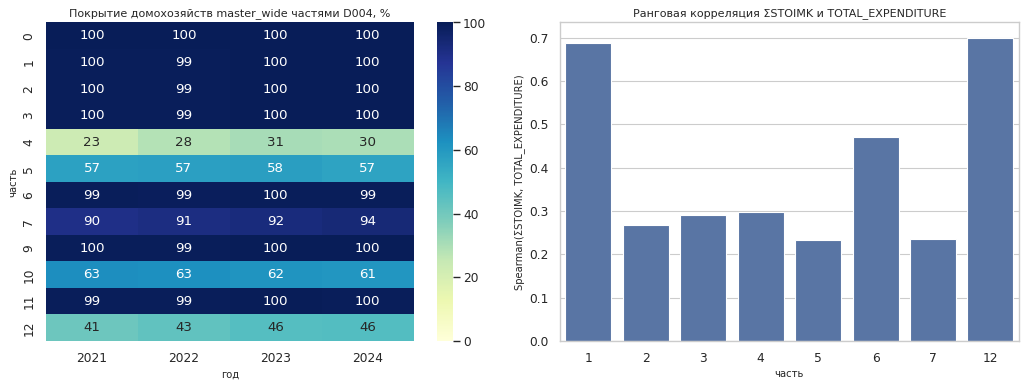

In [28]:
res = []
for y in YEARS:
    ms = set(HHSET[y].tolist())
    for i in KV_PARTS:
        t = D4HH.get(i)
        if t is None: continue
        ds = set(t.loc[t.GOD == y, 'hh'].tolist())
        res.append({'год': y, 'часть': i, 'домохозяйств в части': len(ds), 'покрытие master ч/з часть, %': len(ms & ds) / len(ms) * 100, 'доля домохозяйств части, найденных в master, %': (len(ms & ds) / len(ds) * 100) if ds else np.nan})
R = pd.DataFrame(res); FACTS['join'] = {}
cov = R.pivot(index='часть', columns='год', values='покрытие master ч/з часть, %'); back = R.pivot(index='часть', columns='год', values='доля домохозяйств части, найденных в master, %')
h('**Доля домохозяйств master_wide, присутствующих в каждой части D004, %**'); display(cov.round(1))
h('**Доля домохозяйств части D004, найденных в master_wide, %**'); display(back.round(1))
FACTS['join']['cov_min'] = round(float(np.nanmin(cov.values)), 1); FACTS['join']['back_min'] = round(float(np.nanmin(back.values)), 1)
# TE/K согласованность и персоны
if 0 in D4TEK:
    m = pd.concat([HHTEK[y].reset_index().assign(GOD=y).rename(columns={'HOUSEHOLD_ID': 'hh', 'TE': 'TE_m', 'K': 'K_m'}) for y in YEARS]).merge(D4TEK[0].astype({'TE': 'float', 'K': 'float'}), on=['GOD', 'hh'], how='inner')
    FACTS['join']['te_k_match_pct'] = round(float(((m.TE_m == m.TE) & (m.K_m == m.K)).mean() * 100), 2); FACTS['join']['te_k_pairs'] = int(len(m))
    print(f'Согласованность TE/K между master_wide и D004·kv_vopr_0 для общих домохозяйств: {FACTS["join"]["te_k_match_pct"]}% из {len(m):,} пар')
if 11 in D4PERS:
    pp = D4PERS[11]; out = {}
    for y in YEARS:
        a = {v for (g, v) in pp if g == y}; b = PERS[y]; out[y] = {'лиц master': len(b), 'лиц в kv_vopr_11': len(a), 'в обоих': len(a & b), '% master найдено': round(len(a & b) / len(b) * 100, 1), '% kv11 найдено': round(len(a & b) / max(len(a), 1) * 100, 1)}
    h('**Покрытие лиц (HOUSEHOLD_ID, NOMP): master_wide ↔ kv_vopr_11**'); display(pd.DataFrame(out).T); FACTS['join']['persons'] = out
# переиспользование номеров домохозяйств между годами
ov = {}
for a, b in zip(YEARS[:-1], YEARS[1:]):
    x = HHTEK[a].join(HHTEK[b], lsuffix='_a', rsuffix='_b', how='inner'); ov[f'{a}→{b}'] = round(float(((x.TE_a == x.TE_b) & (x.K_a == x.K_b)).mean() * 100), 1)
FACTS['join']['te_k_same_hhid_across_years_pct'] = ov; print('Доля HOUSEHOLD_ID с тем же (TE,K) в соседних годах (проверка «панельности» нумерации):', ov)
# согласованность расходов: сумма STOIMK части D004 vs TOTAL_EXPENDITURE master (домохозяйство × квартал)
TE = pd.concat(TOTEXP.values()).rename(columns={'HOUSEHOLD_ID': 'hh'}); rr = []
for i, a in D4AGG.items():
    m = a.merge(TE, on=['GOD', 'hh', 'KVARTAL'], how='inner'); m = m[(m.v > 0) & (m.te > 0)]
    if len(m) > 50: rr.append({'часть': i, 'пар дом-квартал': len(m), 'Spearman(ΣSTOIMK, TOTAL_EXPENDITURE)': m.v.corr(m.te, method='spearman'), 'медиана ΣSTOIMK / TOTAL_EXPENDITURE': (m.v / m.te).median()})
Rr = pd.DataFrame(rr); h('**Проверка согласованности (исследовательская: смысл STOIMK по частям не подтверждён опросником)**')
if len(Rr): display(Rr.round(3)); FACTS['join']['stoimk_vs_te'] = Rr.round(3).to_dict('records')
fig, ax = plt.subplots(1, 2, figsize=(13, 5)); sns.heatmap(cov, annot=True, fmt='.0f', cmap='YlGnBu', vmin=0, vmax=100, ax=ax[0]); ax[0].set_title('Покрытие домохозяйств master_wide частями D004, %')
if len(Rr): sns.barplot(data=Rr, x='часть', y='Spearman(ΣSTOIMK, TOTAL_EXPENDITURE)', ax=ax[1], color='#4c72b0'); ax[1].set_title('Ранговая корреляция ΣSTOIMK и TOTAL_EXPENDITURE'); ax[1].axhline(0, c='k', lw=.5)
plt.tight_layout(); plt.show()

**Выводы.** Ключ NOMER = год·10⁶ + HOUSEHOLD_ID подтверждён: все домохозяйства master_wide есть в D004 (и наоборот), TE/K совпадают в 100% из 48 000 пар. Но `HOUSEHOLD_ID` не панельный (тот же TE/K в соседних годах лишь у 2–6%) — динамику по нему строить нельзя. kv_vopr_11 покрывает ~62% лиц master (обратно 100%). ΣSTOIMK и `TOTAL_EXPENDITURE` согласованы умеренно (ρ≈0,7 для частей 1 и 12, 0,2–0,5 для остальных) — смысл полей различается.

# Ключевые находки и проблемы качества данных
1. **Связность подтверждена:** `NOMER = год·10⁶ + HOUSEHOLD_ID`, TE/K совпадают в 100% случаев, все домохозяйства master_wide присутствуют в D004; в master_wide нет дубликатов по ключу и полных дубликатов.
2. **Много «мёртвых» колонок в master_wide:** 126–190 из 510 колонок пусты полностью (по годам), ещё 70–105 константны; блок D002 (224 колонки) заполнен лишь в ~28% строк.
3. **Формы менялись:** 226 колонок пусты не во всех годах, у 56 кодированных колонок набор значений резко меняется (47 — D006). Одинаковое имя ≠ одинаковый смысл.
4. **Артефакты слияния:** `NOMER_x` и `NOMER_y` совпадают лишь в <1% строк, `GODO_x/GODO_y` пусты в ~72% строк — назначение и происхождение неясны.
5. **`TOTAL_EXPENDITURE` — показатель домохозяйства**, повторённый по лицам (100% случаев); пропусков 1,2–1,5%. Строчные статистики завышают вес крупных домохозяйств.
6. **Дубликаты в D004:** полные дубликаты есть во всех частях, кроме 0 и 11 (максимум: kv_9 — 2,1%, kv_1 — 17,6 тыс.); естественный ключ частей не определён (много повторов по NOMER+KVARTAL+код).
7. **Пустые/разреженные поля D004:** `PRIZ` (kv_1) и `KOD` (kv_6) пусты на 100%; в kv_9 и kv_12 многие поля пусты на 45–86%.
8. **Распределения:** денежные и счётные величины сильно скошены вправо, выбросы по IQR 2–16% в выборках; многие числовые колонки разрежены (IQR=0).
9. **Нумерация домохозяйств не панельная:** один и тот же `HOUSEHOLD_ID` в соседних годах имеет одинаковые TE/K лишь в 2–6% случаев.
10. **Неполное покрытие лиц и частей:** kv_vopr_11 охватывает ~62% лиц master_wide; редкие части (kv_4, 5, 10, 12) содержат 20–60% домохозяйств; кварталы в kv_10 и kv_4 представлены неравномерно (min/max ≈0,5).

# Рекомендации для дальнейшей работы
1. **Собрать кодбук по годам** (колонка × год → смысл/шкала), начав с 56+226 помеченных колонок и блока D006; до этого не объединять годы в один ряд.
2. **Очистить master_wide:** убрать пустые/константные колонки и артефакты `_x/_y`, кодированные признаки хранить как `category`, целевые таблицы — в parquet.
3. **Правильный уровень анализа:** расходы — на уровне домохозяйство×квартал (без повторов по лицам); анализ лиц — через `HOUSEHOLD_ID`+`NOMP`; проверить наличие и смысл весов/репрезентативности.
4. **D004:** по структуре определить ключ каждой части, затем аккуратно удалить полные дубликаты (сначала сверить с источником); исключить `PRIZ`, `KOD`.
5. **Денежные величины:** логарифм/винзоризация для моделей; при сравнении лет учитывать номинальные значения (нужна дефляция).
6. **Уточнить у владельцев данных:** критерий отбора лиц в kv_vopr_11, причину заполненности D002 лишь в ~28% строк, неравномерность кварталов в kv_10/kv_4 и нумерацию домохозяйств между годами.
7. **Следующий шаг EDA:** тематические срезы (по TE/K, размеру домохозяйства, кварталам) после согласования кодбука; сравнение годов только для колонок с подтверждённой сопоставимостью.

In [30]:
json.dump(FACTS, open(os.environ.get('NB_FACTS', 'facts.json'), 'w'), ensure_ascii=False, default=lambda o: o.item() if hasattr(o, 'item') else str(o))
print('Готово: сводка фактов сохранена.')

Готово: сводка фактов сохранена.
